In [34]:
import os
import sys
import anndata as ad
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import metacells as mc
from itertools import combinations

f_dir = os.path.dirname(os.path.abspath("__file__"))  
project_root = os.path.abspath(os.path.join(f_dir, "..", ".."))
sys.path.append(os.path.abspath(os.path.join(f_dir, "..", "..", "utils")))

import constants
import utils

import tqdm 
import time

from statsmodels.stats.multitest import multipletests
import matplotlib.ticker as mticker

from scipy.stats import wilcoxon, ks_2samp
from scipy.stats import chi2


%load_ext autoreload
%autoreload 2

sb.set_context("talk")
rng = np.random.default_rng(seed=42)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
os.makedirs("./output", exist_ok=True)

In [36]:
data_path = os.path.join(project_root, "data", "clonal_memory_data")

In [37]:
def get_observed_cells_ad(full_cells_ad, trajectory, min_clone_size, cell_target_umis=2**11):
    trajectory_top_level_cell_type = constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]

    cells_ad = mc.ut.slice(full_cells_ad, obs=full_cells_ad.obs.top_level_cell_type.isin(trajectory_top_level_cell_type))
    trajectory_cells_ad = mc.ut.slice(cells_ad, obs=cells_ad.obs.top_level_cell_type.isin(trajectory_top_level_cell_type))
    trajectory_cells_ad = mc.ut.slice(trajectory_cells_ad, obs=trajectory_cells_ad.obs.clone_exp_id.isin(trajectory_cells_ad.obs.clone_exp_id.value_counts()[trajectory_cells_ad.obs.clone_exp_id.value_counts() >= min_clone_size].index))
    observed_cells_addata = trajectory_cells_ad.copy()
    observed_cells_addata = utils.downsample_cells(anndata=observed_cells_addata, target_umis=cell_target_umis, cut_downsampled=True)

    return observed_cells_addata, cells_ad

def get_trajectory_metacells(metacells_ad, metacell_umis_df_sampled, trajectory):
    trajectory_top_level_cell_type = constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory]

    trajectory_metacells_ad = mc.ut.slice(metacells_ad, obs=metacells_ad.obs.top_level_cell_type.isin(trajectory_top_level_cell_type))
    trajectory_metacell_umis_df_sampled = metacell_umis_df_sampled.loc[trajectory_metacells_ad.obs_names]
    return trajectory_metacell_umis_df_sampled, trajectory_metacells_ad

def safe_multinomial_counts(vals, n, rng):
    # vals: 1D array of nonnegative weights (UMIs per gene for one metacell)
    w = np.asarray(vals, dtype=float)
    w[~np.isfinite(w)] = 0.0          # drop NaN/inf
    w = np.maximum(w, 0.0)            # no negatives
    tot = w.sum()
    if tot <= 0 or n == 0:
        return np.zeros_like(w, dtype=int)
    p = w / tot
    # re-normalize to kill drift, then force exact sum=1
    s = p.sum()
    if not np.isclose(s, 1.0):
        p /= s
    p[-1] = max(0.0, 1.0 - p[:-1].sum())  # guard: sum(p)=1
    return rng.multinomial(int(n), p)


def sample_metacells(df, target_umis, random_state=None):
    rng = np.random.default_rng(random_state)
    out = [pd.Series(safe_multinomial_counts(row.values, target_umis, rng),
                     index=df.columns, name=idx)
           for idx, row in df.iterrows()]
    return pd.DataFrame(out,)

In [38]:
cells_ad = ad.read_h5ad(constants.CELLS_PATH)
metacells_ad = ad.read_h5ad(constants.METACELLS_PATH)
cell_type_colors = pd.read_csv(constants.CELLS_TYPE_COLORS, index_col=0).to_dict()['color']

cells_ad = mc.ut.slice(cells_ad, obs=cells_ad.obs.clone_id.notna())

cells_with_clones_info = mc.ut.slice(cells_ad, obs = ~cells_ad.obs.clone_id.isin(["nan", "unknown", "doublets"]))
cells_with_clones_info = mc.ut.slice(cells_with_clones_info, obs=cells_with_clones_info.obs.clone_id.notna())

clone_counts = cells_with_clones_info.obs['clone_exp_id'].value_counts()
valid_clone_ids = clone_counts[clone_counts > 1].index

cells_with_clones = cells_with_clones_info[cells_with_clones_info.obs['clone_exp_id'].isin(valid_clone_ids)]


globin_genes = ["HBG1","HBG2","HBA1","HBA2","HBZ","HBB", 'HBD', "HBE1"]
lateral_genes = cells_ad.var_names[cells_ad.var.lateral_gene].difference(globin_genes).difference(["RNASE2"])

In [39]:
target_umis = cell_target_umis =  2**11
min_clone_size = 8

## Aggrigate data 

In [41]:
def get_observed_expected_clones_ad(observed_cells_addata, trajectory_metacell_umis_df_sampled, is_deterministic=True):
    # closest_idx = observed_cells_addata.obs.Ery_pseudotime.apply(lambda x: np.abs(trajectory_metacells_ad.obs.Ery_pseudotime - x).idxmin())
    clones_obs_umis_df = utils.get_metacells_umis_df(cells_anndata = observed_cells_addata, group_name="clone_exp_id", layer="downsampled")
    
    if is_deterministic:
        closest_idx = observed_cells_addata.obs.metacell_name
        mc_to_clone_id = pd.Series(observed_cells_addata[closest_idx.index].obs.clone_exp_id.values, index=closest_idx.values)

        clones_exp_umis_df = trajectory_metacell_umis_df_sampled.loc[closest_idx.values].groupby(mc_to_clone_id).sum() 
        clones_exp_umis_df = clones_exp_umis_df.astype(np.float32)
        
    else:
        clones_exp_umis_df = trajectory_metacell_umis_df_sampled.groupby(observed_cells_addata.obs.clone_exp_id).sum()
        clones_exp_umis_df = clones_exp_umis_df.reindex_like(clones_obs_umis_df)
        clones_exp_umis_df = clones_exp_umis_df.astype(np.float32)

    return clones_obs_umis_df, clones_exp_umis_df

def get_nonzero_clones_umis(clones_obs_umis_df, clones_exp_umis_df):
    clones_exp_umis_df = clones_exp_umis_df.reindex_like(clones_obs_umis_df)

    obs, exp = clones_obs_umis_df.to_numpy(), clones_exp_umis_df.to_numpy()
    mask = (obs != 0) | (exp != 0)
    r, c = np.nonzero(mask)

    idx = pd.MultiIndex.from_arrays(
        [clones_obs_umis_df.index.to_numpy()[r],
         clones_obs_umis_df.columns.to_numpy()[c]],
        names=["clone_exp_id", "gene"]
    )

    return (
        pd.Series(obs[r, c], index=idx, name="obs"),
        pd.Series(exp[r, c], index=idx, name="exp"),
    )
    
def get_all_clones_umis(clones_obs_umis_df, clones_exp_umis_df):
    # align
    clones_exp_umis_df = clones_exp_umis_df.reindex_like(clones_obs_umis_df)

    # views
    obs = clones_obs_umis_df.to_numpy()
    exp = clones_exp_umis_df.to_numpy()
    n_r, n_c = obs.shape

    # MultiIndex once
    rows = np.repeat(clones_obs_umis_df.index.to_numpy(), n_c)
    cols = np.tile(clones_obs_umis_df.columns.to_numpy(), n_r)
    idx = pd.MultiIndex.from_arrays([rows, cols], names=["clone_exp_id", "gene"])

    # flatten
    obs_s = pd.Series(obs.ravel(order="C"), index=idx, name="obs")
    exp_s = pd.Series(exp.ravel(order="C"), index=idx, name="exp")
    return obs_s, exp_s

    
    
def build_clone_pos(cells_index, clone_series):
    """Return dict: clone_id -> np.array of integer positions aligned to observed_cells_df."""
    # clone_series index must match cells_index order
    assert (cells_index == clone_series.index).all(), "Indices misaligned"
    ids = clone_series.values
    uniq = pd.Index(ids).unique()
    return {cid: np.where(ids == cid)[0] for cid in uniq}

def wilcoxon_gene_matrix(O, E, *, min_pairs=3):
    """
    O,E: arrays (cells, genes). Returns median_diff, pvals over the KEPT genes.
    NaN-safe: drops NaN pairs per gene. Requires >= min_pairs nonzero diffs.
    """
    G = O.shape[1]
    med = np.empty(G, dtype=float)
    p   = np.ones(G, dtype=float)
    D   = O - E  # compute once

    for j in range(G):
        o = O[:, j]; e = E[:, j]
        # paired NaN filter
        ok = np.isfinite(o) & np.isfinite(e)
        if not np.any(ok):
            med[j] = np.nan; p[j] = 1.0; continue

        d = (o[ok] - e[ok]).astype(float, copy=False)
        med[j] = np.nanmedian(d)  # median on the kept pairs

        # need enough nonzero diffs for Wilcoxon to be defined
        if np.count_nonzero(d) >= min_pairs:
            try:
                res = wilcoxon(d, zero_method="pratt", alternative="two-sided", method="auto")
                p[j] = float(res.pvalue)
            except ValueError:
                p[j] = 1.0
        else:
            p[j] = 1.0
    return med, p

# ---------- main runner ----------
def run_paired_wilcoxon_all_clones(
    observed_cells_df: pd.DataFrame,
    expected_cells_df: pd.DataFrame,
    clone_series: pd.Series,  # cells_ad.obs.clone_exp_id aligned to observed_cells_df.index
    progress: bool = True,
    do_probe: bool = True,
    min_sum=0,
    min_pairs=3,
    min_expression=0,
    min_expression_cells=0.2,
):
    """
    Paired Wilcoxon per (clone, gene). Global BH-FDR at the end.
    - observed_cells_df, expected_cells_df: cells×genes, same index and columns.
    - clone_series: length=cells, index identical to observed_cells_df.index.
    """
    # Align and validate
    assert observed_cells_df.shape == expected_cells_df.shape, "Obs/Exp shapes differ"
    assert (observed_cells_df.index == expected_cells_df.index).all(), "Obs/Exp index differ"
    assert (observed_cells_df.columns == expected_cells_df.columns).all(), "Obs/Exp columns differ"

    # Build integer positions per clone for fast iloc
    clone_pos = build_clone_pos(observed_cells_df.index, clone_series)
    genes = observed_cells_df.columns.to_numpy()

    # Optional probe to measure actual throughput on your hardware and data
    if do_probe:
        probe_clone = next(iter(clone_pos.keys()))
        pos = clone_pos[probe_clone]
        O_probe = observed_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)
        E_probe = expected_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)
        keep_probe = ((O_probe.sum(axis=0) >= min_sum) | (E_probe.sum(axis=0) >= min_sum)) & (((E_probe >= min_expression).mean(axis=0) >= min_expression_cells) | ((O_probe >= min_expression).mean(axis=0) >= min_expression_cells))
        if keep_probe.any():
            Op, Ep = O_probe[:, keep_probe], E_probe[:, keep_probe]
            m = min(200, Op.shape[1])
            t0 = time.perf_counter()
            _ = wilcoxon_gene_matrix(Op[:, :m], Ep[:, :m], min_pairs=min_pairs)
            t1 = time.perf_counter()
            per_test = (t1 - t0) / max(m, 1)
            # rough total = sum kept genes over clones
            approx_total = 0
            for cid in clone_pos:
                pos_c = clone_pos[cid]
                Oc = observed_cells_df.iloc[pos_c].to_numpy(dtype=float, copy=False)
                Ec = expected_cells_df.iloc[pos_c].to_numpy(dtype=float, copy=False)
                approx_total += ((Oc.sum(axis=0) >= min_sum) | (Ec.sum(axis=0) >= min_sum)).sum()
            print(f"[probe] kept_genes_probe={Op.shape[1]}, per-gene ≈ {per_test:.6f}s, ~total tests ≈ {approx_total}")
        else:
            print("[probe] no genes pass min_sum for probe clone")

    rows = []
    t_start = time.perf_counter()
    iterator = tqdm.tqdm(clone_pos.items(), total=len(clone_pos), smoothing=0.1) if progress else clone_pos.items()

    for cid, pos in iterator:
        O = observed_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)
        E = expected_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)

        # per-clone gene filter by sums
        keep = ((O.sum(axis=0) >= min_sum) | (E.sum(axis=0) >= min_sum)) & (((E >= min_expression).mean(axis=0) >= min_expression_cells) | ((O >= min_expression).mean(axis=0) >= min_expression_cells))
        if not np.any(keep):
            continue

        O = O[:, keep]; E = E[:, keep]
        kept_genes = genes[keep]

        med, p = wilcoxon_gene_matrix(O, E, min_pairs=min_pairs)
        row = pd.DataFrame({
            "clone": cid,
            "gene": kept_genes,
            "median_diff": med,
            "pval": p
        })
        # row["pval_adj"] = multipletests(row["pval"], method="fdr_bh")[1]
        rows.append(row)


    if not rows:
        return pd.DataFrame(columns=["clone","gene","median_diff","pval","direction"])


    final_df = pd.concat(rows, ignore_index=True)
    # final_df["pval_adj"] = multipletests(final_df["pval"], method="fdr_bh")[1]

    elapsed = time.perf_counter() - t_start
    n_tests = final_df.shape[0]
    rate = n_tests / max(elapsed, 1e-9)
    print(f"[run] tests={n_tests}, elapsed={elapsed:.2f}s, throughput={rate:.1f} tests/s")
    return final_df

def run_chisq_filtered(
    observed_cells_df: pd.DataFrame,
    expected_cells_df: pd.DataFrame,
    clone_series: pd.Series,
    wil_df: pd.DataFrame,
    p_thresh: float = 0.01,
    progress: bool = True,
    # n_eff_threshold = 3,  # at least 3 cells with O!=E to compute direction
    frac_pos_threshold = 0.75,  # at least 75% of non-tied cells in one direction to assign direction
    
):
    """
    Run chi-square only on (clone,gene) pairs with Wilcoxon p < p_thresh,
    assign chi² p=1 for others, then do global BH-FDR correction.
    """
    # prepare lookup structure
    subset = set(map(tuple, wil_df.loc[wil_df["pval"] < p_thresh, ["clone", "gene"]].to_numpy()))
    clone_pos = {cid: np.where(clone_series == cid)[0] for cid in np.unique(clone_series)}

    records = []
    iterator = tqdm.tqdm(wil_df.itertuples(index=False), total=len(wil_df), disable=not progress)

    for row in iterator:
        cid, gene, wil_p = row.clone, row.gene, row.pval
        pos = clone_pos[cid]
        if (cid, gene) in subset:
            # compute chi-square
            O = observed_cells_df.iloc[pos][gene].to_numpy(float)
            E = expected_cells_df.iloc[pos][gene].to_numpy(float)
            msk = np.isfinite(O) & np.isfinite(E)
            
            total_cells_in_clone = msk.sum()
            n_eff_min = min(10, max(3, int(0.05 * total_cells_in_clone)))  # at least 5 cells will be difference with delta
            
            nz  = msk & (O != E)                      # ignore ties for direction
            n_eff = int(nz.sum())

            diff, stat, p = chi_square_gene_sums(O[:, None], E[:, None])
            frac_pos = np.mean(O > E) if n_eff > 0 else np.nan
            frac_neg = np.mean(O < E) if n_eff > 0 else np.nan
            frac_eq = np.mean(O == E) if n_eff > 0 else np.nan
            if frac_pos >= frac_pos_threshold:               
                sign_majority = +1
            elif frac_neg >= frac_pos_threshold:       
                sign_majority = -1
            else:                             
                sign_majority = 0
            
            # Not enough delta cells to decide 
            if n_eff < n_eff_min:
                sign_majority = 0   
            sign_sum = np.sign(diff)[0]
            records.append((cid, gene, diff[0], stat[0], p[0], wil_p, frac_pos, frac_neg, frac_eq, sign_majority, sign_sum))
            
        else:
            # skip computation
            records.append((cid, gene, 0.0, 0.0, 1.0, wil_p, np.nan, np.nan,np.nan, 0, 0))

    df = pd.DataFrame(records, columns=[
        "clone","gene","obs_minus_exp_sum","chisq_stat","chisq_pval","wilcoxon_pval", "frac_pos","frac_neg","frac_eq","direction_majority","direction_sum"
    ])
    
    df["chisq_pval_adj"] = multipletests(df["chisq_pval"], method="fdr_bh")[1]
    
    return df

def chi_square_gene_sums(O, E, *, eps=1e-12):
    """
    O,E: arrays (cells, genes).
    Returns (diff, stat, pvals) per gene based on *sums* across cells.
    NaN-safe: ignores non-finite pairs.
    """
    # paired NaN handling per entry
    mask = np.isfinite(O) & np.isfinite(E)
    Oc = np.where(mask, O, 0.0)
    Ec = np.where(mask, E, 0.0)

    # sums across cells
    O_sum = Oc.sum(axis=0)
    E_sum = Ec.sum(axis=0)

    # Pearson chi-square with 1 df
    stat = (O_sum - E_sum)**2 / np.clip(E_sum, eps, None)
    p = chi2.sf(stat, df=1)

    diff = O_sum - E_sum  # signed effect size
    return diff, stat, p

def run_chisq_on_summed_counts_all_clones(
    observed_cells_df: pd.DataFrame,
    expected_cells_df: pd.DataFrame,
    clone_series: pd.Series,           # cells_ad.obs.clone_exp_id aligned to observed_cells_df.index
    progress: bool = True,
    do_probe: bool = True,
    min_sum=0,                         # keep gene if max(sum_O, sum_E) >= min_sum
    min_expression=0,                  # per-cell expression threshold
    min_expression_cells=0.2,          # fraction of cells passing min_expression in either O or E
):
    """
    Pearson chi-square on *summed counts* per (clone,gene).
    Global BH-FDR at the end.
    - observed_cells_df, expected_cells_df: cells×genes, same index and columns.
    - clone_series: length=cells, index identical to observed_cells_df.index.
    """
    assert observed_cells_df.shape == expected_cells_df.shape, "Obs/Exp shapes differ"
    assert (observed_cells_df.index == expected_cells_df.index).all(), "Obs/Exp index differ"
    assert (observed_cells_df.columns == expected_cells_df.columns).all(), "Obs/Exp columns differ"

    # Build integer positions per clone
    def build_clone_pos(index, clone_series):
        # same helper you already use
        pos = {}
        ser = clone_series.reindex(index)
        for cid, ix in ser.groupby(ser).groups.items():
            pos[cid] = np.fromiter((i for i,_ in enumerate(index) if index[i] in ix), dtype=int)
        return pos

    clone_pos = build_clone_pos(observed_cells_df.index, clone_series)
    genes = observed_cells_df.columns.to_numpy()

    # Optional probe
    if do_probe and len(clone_pos) > 0:
        probe_clone = next(iter(clone_pos.keys()))
        pos = clone_pos[probe_clone]
        O_probe = observed_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)
        E_probe = expected_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)
        keep_probe = ((O_probe.sum(axis=0) >= min_sum) | (E_probe.sum(axis=0) >= min_sum)) & \
                     (((E_probe >= min_expression).mean(axis=0) >= min_expression_cells) | \
                      ((O_probe >= min_expression).mean(axis=0) >= min_expression_cells))
        m = min(200, int(keep_probe.sum()))
        if m > 0:
            t0 = time.perf_counter()
            _ = chi_square_gene_sums(O_probe[:, keep_probe][:, :m], E_probe[:, keep_probe][:, :m])
            t1 = time.perf_counter()
            per_test = (t1 - t0) / m
            approx_total = 0
            for cid in clone_pos:
                pos_c = clone_pos[cid]
                Oc = observed_cells_df.iloc[pos_c].to_numpy(dtype=float, copy=False)
                Ec = expected_cells_df.iloc[pos_c].to_numpy(dtype=float, copy=False)
                approx_total += ((Oc.sum(axis=0) >= min_sum) | (Ec.sum(axis=0) >= min_sum)).sum()
            print(f"[probe χ²] kept_genes_probe={keep_probe.sum()}, per-gene ≈ {per_test:.6f}s, ~total tests ≈ {approx_total}")
        else:
            print("[probe χ²] no genes pass thresholds for probe clone")

    rows = []
    t_start = time.perf_counter()
    iterator = tqdm.tqdm(clone_pos.items(), total=len(clone_pos), smoothing=0.1) if progress else clone_pos.items()

    for cid, pos in iterator:
        O = observed_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)
        E = expected_cells_df.iloc[pos].to_numpy(dtype=float, copy=False)

        keep = ((O.sum(axis=0) >= min_sum) | (E.sum(axis=0) >= min_sum)) & \
               (((E >= min_expression).mean(axis=0) >= min_expression_cells) | \
                ((O >= min_expression).mean(axis=0) >= min_expression_cells))
        if not np.any(keep):
            continue

        Ok, Ek = O[:, keep], E[:, keep]
        kept_genes = genes[keep]

        diff, stat, p = chi_square_gene_sums(Ok, Ek)
        row = pd.DataFrame({
            "clone": cid,
            "gene": kept_genes,
            "obs_minus_exp_sum": diff,
            "chisq_stat": stat,
            "chisq_pval": p,
        })
        row["direction"] = np.sign(row["obs_minus_exp_sum"]).astype(int)
        rows.append(row)

    if not rows:
        return pd.DataFrame(columns=["clone","gene","obs_minus_exp_sum","chisq_stat","chisq_pval","direction"])

    final_df = pd.concat(rows, ignore_index=True)
    final_df["chisq_pval_adj"] = multipletests(final_df["chisq_pval"], method="fdr_bh")[1]
    elapsed = time.perf_counter() - t_start
    n_tests = final_df.shape[0]
    rate = n_tests / max(elapsed, 1e-9)
    print(f"[run χ²] tests={n_tests}, elapsed={elapsed:.2f}s, throughput={rate:.1f} tests/s")
    return final_df

In [43]:
metacell_umis_df = utils.get_metacells_umis_df(cells_anndata = cells_ad, group_name="metacell_name")
metacell_umis_df = metacell_umis_df.div(metacell_umis_df.sum(axis=1), axis=0)
metacell_umis_df_sampled = metacell_umis_df * target_umis

cells_metacell_umis_df = metacell_umis_df.loc[cells_ad.obs.metacell_name]
cells_metacell_umis_df.index = cells_ad.obs_names
cells_metacell_umis_df_sampled = sample_metacells(cells_metacell_umis_df, target_umis=cell_target_umis, random_state=42)

In [44]:
trajectory_information_dict = {}
full_cells_ad = cells_ad.copy()

In [ ]:
for trajectory in tqdm.tqdm(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT):
    print(trajectory)
    
    observed_cells_addata, cells_ad = get_observed_cells_ad(full_cells_ad, trajectory, min_clone_size, cell_target_umis=cell_target_umis) 
    observed_cells_df = mc.ut.get_vo_frame(observed_cells_addata, "downsampled")
    trajectory_metacell_umis_df_sampled, trajectory_metacells_ad = get_trajectory_metacells(metacells_ad, metacell_umis_df_sampled,trajectory)
    trajectory_cells_metacell_umis_df_sampled = cells_metacell_umis_df_sampled.loc[observed_cells_addata.obs_names]

    clones_obs_umis_df, clones_exp_umis_df = get_observed_expected_clones_ad(observed_cells_addata, trajectory_cells_metacell_umis_df_sampled, is_deterministic=False)
    clones_obs_umis_df_stacked_nonzero, clones_exp_umis_df_stacked_nonzero = get_nonzero_clones_umis(clones_obs_umis_df, clones_exp_umis_df)
    clones_obs_umis_df_stacked_nonzero_with_epsilon = clones_obs_umis_df_stacked_nonzero + 1
    clones_exp_umis_df_stacked_nonzero_with_epsilon = clones_exp_umis_df_stacked_nonzero + 1
    clones_exp_umis_df_stacked_nonzero_logfold = np.log2(clones_obs_umis_df_stacked_nonzero_with_epsilon / clones_exp_umis_df_stacked_nonzero_with_epsilon)

    cells_ad_with_clones = cells_ad[observed_cells_df.index]
    trajectory_cells_metacell_umis_df_sampled = trajectory_cells_metacell_umis_df_sampled.reindex_like(observed_cells_df)


    cells_ad_with_clones = cells_ad[observed_cells_df.index]  # ensure alignment upstream if needed
    
    wil_df = run_paired_wilcoxon_all_clones(
        observed_cells_df=observed_cells_df,
        expected_cells_df=trajectory_cells_metacell_umis_df_sampled,
        clone_series=cells_ad_with_clones.obs['clone_exp_id'],
        progress=True,
        do_probe=True,
        min_sum=2**3,
        min_expression=4
    )

    final_df = run_chisq_filtered(
        observed_cells_df=observed_cells_df,
        expected_cells_df=trajectory_cells_metacell_umis_df_sampled,
        clone_series=cells_ad_with_clones.obs['clone_exp_id'],
        wil_df=wil_df,
        p_thresh=0.01,
        progress=True,
    )
    final_df_full = final_df.copy()
    final_df["significant"] = (final_df["wilcoxon_pval"] < 0.01) & (final_df["chisq_pval_adj"] < 0.05)
    final_df["direction_agreement"] = final_df["direction_majority"] == final_df["direction_sum"]
    final_df["valid_gene"] = final_df["significant"] & final_df["direction_agreement"]

    clones_genes_with_significant = final_df[final_df.valid_gene]
    clones_genes_with_significant_tuples = clones_genes_with_significant.set_index(["clone","gene"]).index

    clones_obs_umis_df_stacked, clones_exp_umis_df_stacked = get_all_clones_umis(clones_obs_umis_df, clones_exp_umis_df)
    clones_obs_umis_df_stacked = clones_obs_umis_df_stacked + 1
    clones_exp_umis_df_stacked = clones_exp_umis_df_stacked + 1
    clones_exp_umis_df_stacked_logfold = np.log2(clones_obs_umis_df_stacked / clones_exp_umis_df_stacked)

    trajectory_information_dict[trajectory] = {
        "final_df_full": final_df_full,
        "all_wilcoxon_results_df": final_df,
        "clones_genes_with_significant_tuples": clones_genes_with_significant_tuples,
        "clones_obs_umis_df_stacked_nonzero_with_epsilon": clones_obs_umis_df_stacked_nonzero_with_epsilon,
        "clones_exp_umis_df_stacked_nonzero_with_epsilon": clones_exp_umis_df_stacked_nonzero_with_epsilon,
        "observed_cells_addata": observed_cells_addata,
        "trajectory_metacell_umis_df_sampled": trajectory_metacell_umis_df_sampled,    
        "trajectory_cells_metacell_umis_df_sampled": trajectory_cells_metacell_umis_df_sampled
    }

  0%|          | 0/7 [00:00<?, ?it/s]

Ery
Downsampling to 2048 UMIs


set unnamed.layers[downsampled]: csr_matrix 21651 X 36497 float32s (24030333 > 0, 3.041%)
set unnamed.uns[downsample_samples]: 2048


Cutting downsampled cells, going to remove 1396 cells (6.45%)


/tmp/ipykernel_1012808/465228620.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clones_exp_umis_df = trajectory_metacell_umis_df_sampled.groupby(observed_cells_addata.obs.clone_exp_id).sum()


...

/tmp/ipykernel_1012808/465228620.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clones_exp_umis_df = trajectory_metacell_umis_df_sampled.groupby(observed_cells_addata.obs.clone_exp_id).sum()


[probe] kept_genes_probe=117, per-gene ≈ 0.000274s, ~total tests ≈ 44157


/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
100%|██████████| 16/16 [00:00<00:00, 23.12it/s]


[run] tests=1706, elapsed=0.69s, throughput=2456.6 tests/s


100%|██████████| 7/7 [02:54<00:00, 24.96s/it]


In [ ]:
# Use already loaded data to save time 
# utils.save_to_pickle(trajectory_information_dict, os.path.join(data_path, "memory_genes_information_dict.pkl"))
# utils.save_to_pickle(metacell_umis_df_sampled, os.path.join(data_path, "metacell_umis_df_sampled.pkl"))
# utils.save_to_pickle(cells_metacell_umis_df_sampled, os.path.join(data_path, "cells_metacell_umis_df_sampled.pkl"))

## Loading data

In [45]:
full_cells_ad = cells_ad.copy()

In [46]:
# Instead of aggrigating data, we can just load the precomputed information
trajectory_information_dict = utils.load_pickle(os.path.join(data_path, "memory_genes_information_dict.pkl"))
metacell_umis_df_sampled = utils.load_pickle(os.path.join(data_path, "metacell_umis_df_sampled.pkl"))
cells_metacell_umis_df_sampled = utils.load_pickle(os.path.join(data_path, "cells_metacell_umis_df_sampled.pkl"))

In [47]:
all_wilcoxon_results_df_list = []
sign_clones_logfold_list = []
clones_avg_logfold_genes_list = []
final_df_full_list = []
for trajectory in trajectory_information_dict:
    info = trajectory_information_dict[trajectory]
    all_wilcoxon_results_df = info["all_wilcoxon_results_df"]
    all_wilcoxon_results_df["trajectory"] = trajectory
    all_wilcoxon_results_df_list.append(all_wilcoxon_results_df)
    final_df_full = info["final_df_full"]
    
    
    clones_genes_with_significant_tuples = info["clones_genes_with_significant_tuples"]
    clones_obs_umis_df_stacked_nonzero_with_epsilon = info["clones_obs_umis_df_stacked_nonzero_with_epsilon"]
    clones_exp_umis_df_stacked_nonzero_with_epsilon = info["clones_exp_umis_df_stacked_nonzero_with_epsilon"]
    clones_exp_umis_df_stacked_nonzero_logfold = np.log2(clones_obs_umis_df_stacked_nonzero_with_epsilon / clones_exp_umis_df_stacked_nonzero_with_epsilon)

    lateral_rows = clones_genes_with_significant_tuples[clones_genes_with_significant_tuples.get_level_values(1).isin(lateral_genes)]
    non_lateral_rows = clones_genes_with_significant_tuples[~clones_genes_with_significant_tuples.get_level_values(1).isin(lateral_genes)]
    
    genes_with_logfold = clones_exp_umis_df_stacked_nonzero_logfold.loc[non_lateral_rows][clones_exp_umis_df_stacked_nonzero_logfold.loc[non_lateral_rows].abs() >= 1].index.get_level_values(1)
    genes_with_logfold = genes_with_logfold.value_counts()

    sign_clones_logfold = clones_exp_umis_df_stacked_nonzero_logfold[non_lateral_rows][clones_exp_umis_df_stacked_nonzero_logfold[non_lateral_rows].index.get_level_values(1).isin(genes_with_logfold.index)]
    
    all_clones_logfold = clones_exp_umis_df_stacked_nonzero_logfold[clones_exp_umis_df_stacked_nonzero_logfold.index.get_level_values(1).isin(genes_with_logfold.index)]
    clones_avg_logfold_genes = all_clones_logfold.reset_index()

    sign_clones_logfold = clones_exp_umis_df_stacked_nonzero_logfold[non_lateral_rows][clones_exp_umis_df_stacked_nonzero_logfold[non_lateral_rows].index.get_level_values(1).isin(genes_with_logfold.index)]
    sign_clones_logfold = sign_clones_logfold.reset_index()
    
    sign_clones_logfold["trajectory"] = trajectory
    clones_avg_logfold_genes["trajectory"] = trajectory
    final_df_full["trajectory"] = trajectory
    
    sign_clones_logfold_list.append(sign_clones_logfold)
    clones_avg_logfold_genes_list.append(clones_avg_logfold_genes)
    final_df_full_list.append(final_df_full)



all_wilcoxon_results_df = pd.concat(all_wilcoxon_results_df_list)
clones_avg_logfold_genes = pd.concat(clones_avg_logfold_genes_list)
sign_clones_logfold = pd.concat(sign_clones_logfold_list)
final_df_full = pd.concat(final_df_full_list)

clones_avg_logfold_genes.gene = pd.Categorical(clones_avg_logfold_genes.gene, categories=sign_clones_logfold.gene.value_counts().index, ordered=True)
sign_clones_logfold.gene = pd.Categorical(sign_clones_logfold.gene, categories=sign_clones_logfold.gene.value_counts().index, ordered=True)

valid_genes_list = all_wilcoxon_results_df[all_wilcoxon_results_df.valid_gene]
all_wilcoxon_results_df = all_wilcoxon_results_df[all_wilcoxon_results_df.valid_gene]
all_wilcoxon_results_df = all_wilcoxon_results_df[~all_wilcoxon_results_df.gene.isin(lateral_genes)]
all_wilcoxon_results_df = all_wilcoxon_results_df[all_wilcoxon_results_df.trajectory != "Monocyte"] # too few clones


final_df_full = final_df_full[~final_df_full.gene.isin(lateral_genes)]
final_df_full = final_df_full[final_df_full.trajectory != "Monocyte"] # too few clones

## Figure 4A

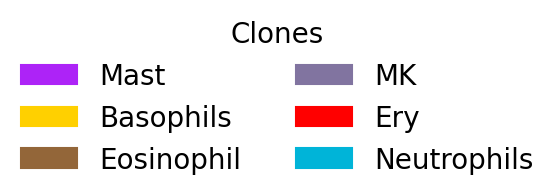

In [48]:
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in ["Mast","Basophils","Eosinophil","MK","Ery","Neutrophils"]}, ncol=2, output_path=os.path.join("./output", "4A_legend.pdf"), title="Clones")
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in ["Mast","Basophils","Eosinophil","MK","Ery","Neutrophils"]}, ncol=2, title="Clones")

In [49]:
# appear in the trajectory more then one time 
all_wilcoxon_results_df = all_wilcoxon_results_df[all_wilcoxon_results_df.groupby(["trajectory", "gene"]).gene.transform("size") > 1]


x = 15  # number of top genes to keep

# count how many times each gene appears per trajectory
gene_counts = (
    all_wilcoxon_results_df
    .groupby(['trajectory', 'gene'])
    .size()
    .reset_index(name='count')
)

# get top x genes per trajectory
top_genes = (
    gene_counts
    .sort_values(['trajectory', 'count'], ascending=[True, False])
    .groupby('trajectory', group_keys=False)
    .head(x)
)

# filter original df to only include those top genes
filtered = all_wilcoxon_results_df.merge(top_genes[['trajectory', 'gene']], on=['trajectory', 'gene'])

filtered_sign_clones_logfold = sign_clones_logfold.merge(
    filtered[['gene', 'trajectory']].drop_duplicates(),
    on=['gene', 'trajectory']
)

filtered_clones_avg_logfold_genes = clones_avg_logfold_genes.merge(
    filtered[['gene', 'trajectory']].drop_duplicates(),
    on=['gene', 'trajectory']
)


/tmp/ipykernel_1012808/446410783.py:85: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



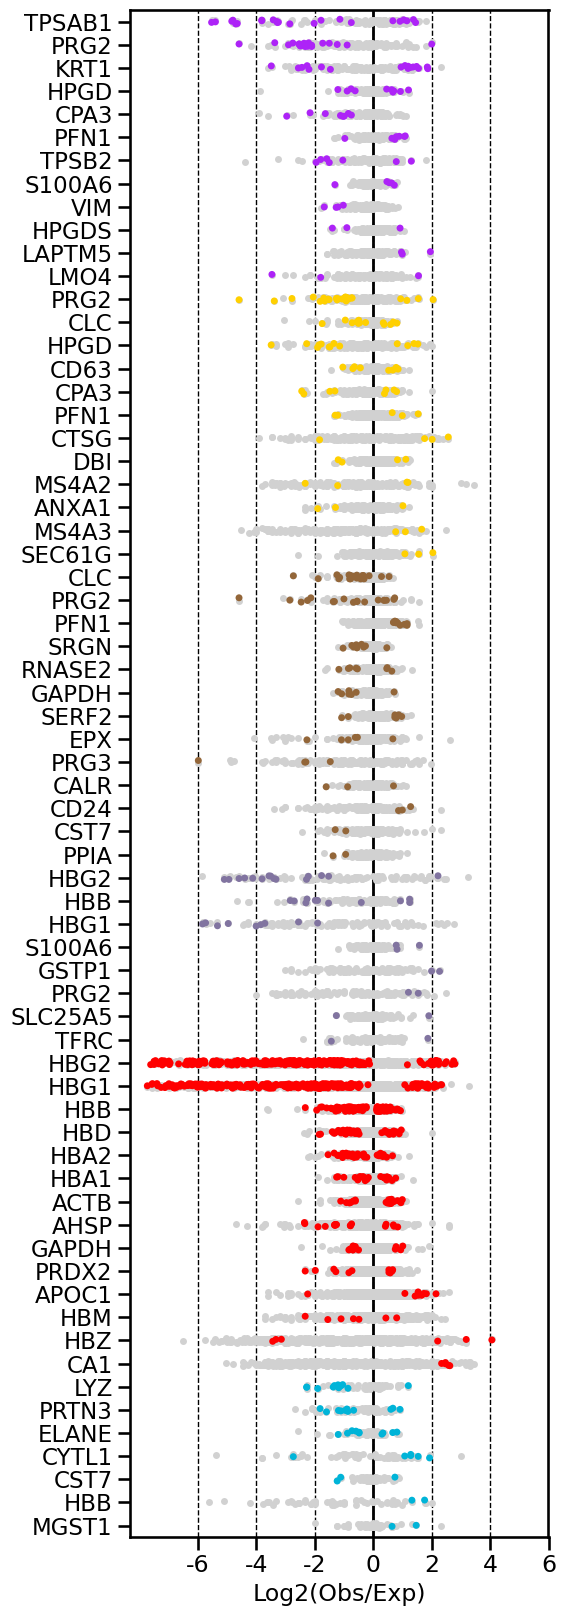

In [50]:
# inputs
df = filtered_sign_clones_logfold.copy()
avg_df = filtered_clones_avg_logfold_genes.copy()
value_col = 0  # or a numeric column like 'logFC'

# trajectory block order from your palette keys; fallback = data order
if 'cell_type_colors' in globals() and isinstance(cell_type_colors, dict) and len(cell_type_colors):
    traj_order = list(cell_type_colors.keys())
else:
    traj_order = pd.Index(pd.concat([df['trajectory'], avg_df['trajectory']])).dropna().unique().tolist()

# all (trajectory, gene) pairs present in either layer
pairs_all = (
    pd.concat([df[['trajectory','gene']], avg_df[['trajectory','gene']]], ignore_index=True)
      .dropna()
      .drop_duplicates()
)

# counts per trajectory for ordering genes
traj_gene_counts = (
    df.groupby(['trajectory','gene'])
      .size()
      .rename('n')
      .reset_index()
)

# build order: for each trajectory block, genes sorted by freq desc then name
order = []
for t in traj_order:
    genes_t = pairs_all.loc[pairs_all['trajectory'] == t, 'gene'].unique().tolist()
    if not genes_t:
        continue
    ct = traj_gene_counts.loc[traj_gene_counts['trajectory'] == t, ['gene','n']].set_index('gene')['n']
    genes_t_sorted = sorted(genes_t, key=lambda g: (-ct.get(g, 0), g))
    order.extend([f"{t} | {g}" for g in genes_t_sorted])

# apply categorical key to both frames
def add_traj_gene(d):
    d = d.copy()
    d['traj_gene'] = d['trajectory'].astype(str) + ' | ' + d['gene'].astype(str)
    d['traj_gene'] = pd.Categorical(d['traj_gene'], categories=order, ordered=True)
    return d

df = add_traj_gene(df)
avg_df = add_traj_gene(avg_df)

# keep rows present in the order
df = df[df['traj_gene'].notna()]
avg_df = avg_df[avg_df['traj_gene'].notna()]

# plot
fig, ax = plt.subplots(figsize=(6, max(3, 0.25 * len(order))))

# background averages in gray
sb.stripplot(
    data=avg_df,
    y='traj_gene',
    x=value_col,
    order=order,
    color='#D1D1D1',       # gray
    size=5,
    jitter=True,
    ax=ax
)

# colored layer; lock hue to trajectory block order
kwargs = {}
if 'cell_type_colors' in globals() and len(cell_type_colors):
    kwargs['palette'] = cell_type_colors
    kwargs['hue_order'] = [t for t in traj_order if t in df['trajectory'].unique()]

sb.stripplot(
    data=df,
    y='traj_gene',
    x=value_col,
    hue='trajectory',
    order=order,
    size=5,
    jitter=True,
    ax=ax,
    **kwargs
)

# y labels: gene only
ax.set_yticklabels([lab.split(' | ', 1)[1] for lab in order])

# cosmetics
ax.set_ylabel('', fontsize=17)
ax.set_xlabel('Log2(Obs/Exp)', fontsize=17)
ax.set_xticks([-6, -4, -2, 0, 2, 4, 6])
ax.set_xticklabels([-6, -4, -2, 0, 2, 4, 6], fontsize=17)

for v in [-6, -4, -2, 0, 2, 4, 6]:
    ax.axvline(v, color='k', linestyle='--', linewidth=1)
    
ax.axvline(0, color='black', linestyle='-', linewidth=2)

# sb.despine(ax=ax)
ax.legend().remove()
plt.tight_layout()
plt.savefig("./output/4A.pdf", dpi=600, bbox_inches='tight')
plt.show()

In [51]:
all_wilcoxon_results_df[all_wilcoxon_results_df.gene == "PRG2"].groupby(["trajectory", "direction_sum"]).clone.count()

trajectory  direction_sum
Basophils   -1.0             24
             1.0              4
Eosinophil  -1.0             12
             1.0              6
Ery          1.0              2
MK           1.0              2
Mast        -1.0             21
             1.0              1
Name: clone, dtype: int64

In [52]:
all_wilcoxon_results_df[(all_wilcoxon_results_df.gene == "HBG1") | (all_wilcoxon_results_df.gene == "HBG2")].groupby(["trajectory", "direction_sum"]).clone.count()

trajectory  direction_sum
Ery         -1.0             541
             1.0              58
MK          -1.0              23
             1.0               1
Name: clone, dtype: int64

## Figure 4B

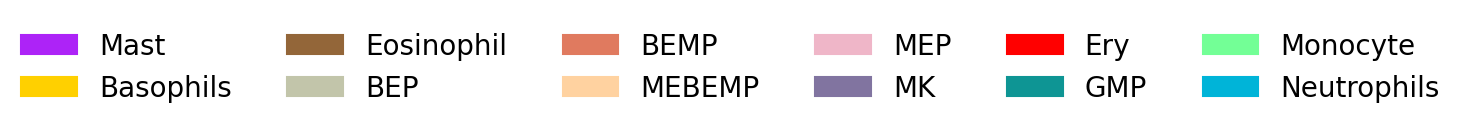

In [53]:
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in cells_ad.obs.top_level_cell_type.unique()}, ncol=6, output_path=os.path.join("./output", "4B_legend.pdf"))
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in cells_ad.obs.top_level_cell_type.unique()}, ncol=6)

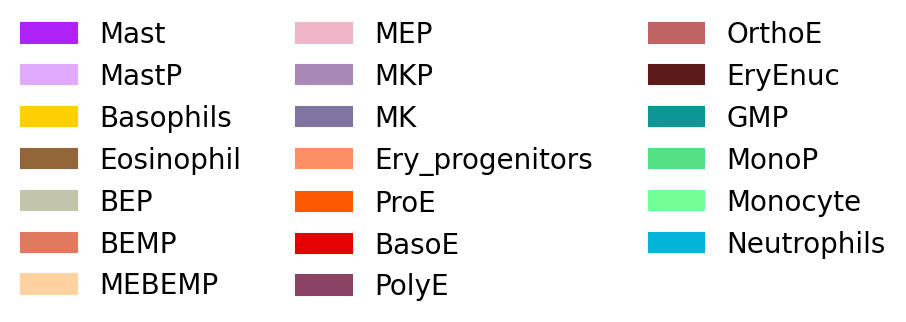

In [54]:
utils.plot_generic_dict_of_colors({i:cell_type_colors[i] for i in cell_type_colors if i in cells_ad.obs.cell_type.unique()}, ncol=3)

In [55]:
import CloneObject

In [56]:
def plot_clones_expression(
    clone_id,
    genes_to_plot,
    observed_semi_df,
    observed_semi_pseudotime,
    trajectory_metacells_pseudotime,
    trajectory_metacells_pseudotime_smoothed_genes,
    output_path=None,
    cells_type=None,
    ylim_max=12,
    col_width=3.2,
    row_height=4,
    fontsize =15,
    file_prefix="",
    s=60
):
    n_genes = len(genes_to_plot)
    fig, axes = plt.subplots(1, n_genes, figsize=(col_width * n_genes, row_height), sharey=False)
    axes = np.atleast_1d(axes)

    # Prepare smoothed trajectory per gene
    pt_mc = trajectory_metacells_pseudotime
    df_sm = trajectory_metacells_pseudotime_smoothed_genes
    traj_by_gene = {}
    for gene in genes_to_plot:
        y = df_sm[gene] 
        m = y.groupby(pt_mc).mean().sort_index()
        traj_by_gene[gene] = (m.index.values, m.values)

    # Observed pseudotime and colors
    pt_obs = np.asarray(getattr(observed_semi_pseudotime, "values", observed_semi_pseudotime)).reshape(-1)
    pt_obs = utils.rand_jitter(pt_obs)  # jitter a bit for better visualization
    colors = [cell_type_colors[c] for c in cells_type] if cells_type is not None else "gray"

    for ax, gene in zip(axes, genes_to_plot):
        x_line, y_line = traj_by_gene[gene]
        ax.plot(x_line, y_line, c="black", linestyle="-", linewidth=1.2)
        ax.scatter(
            pt_obs,
            observed_semi_df[gene].values + 1,
            s=s,
            color=colors,
            rasterized=True,
            alpha=1,
            edgecolors="black", linewidths=0.5
        )

        ax.set_title(gene, fontsize=fontsize)
        ax.set_ylabel("Expression", fontsize=fontsize)
        ax.set_xlabel("Pseudotime", fontsize=fontsize)
        ax.set_yscale("log", base=2)
        ax.set_ylim(2**-1, 2**ylim_max)
        ax.set_xlim(-0.1, 1.1)
        ax.set_yticks([2**i for i in range(-1, ylim_max)])
        ax.grid(axis="y", linestyle="--", color='gray', linewidth=0.5)
        ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.tick_params(axis="x", labelsize=fontsize)
        ax.tick_params(axis="y", labelsize=fontsize)
        
        if genes_to_plot.index(gene) == 0:
            ax.set_ylabel("Expression", fontsize=fontsize)
        else:
            ax.set_ylabel("")

    plt.tight_layout()
    if output_path:
        fig.savefig(os.path.join(output_path, f"{file_prefix}_{clone_id}.pdf"), dpi=600, transparent=False, format="pdf")
    plt.show()
    plt.close(fig)

In [57]:
sliding_window_size = 5

clones_to_show = ["C10_2_III_7", "E19_II_5", "B9_III_6", "D16_II_5","1I0LMJ3K0YLOG8O46XK3ZX64W_I_1", "4JA6S3RQDTU3NOVPJ4Z44GHPL_I_1", "N12_1_III_7"]
clones_to_show_dict = {
    "Mast": (["C10_2_III_7", "E19_II_5"], "TPSAB1", ["TPSAB1", "PRG2", "CPA3","KRT1","HPGD"]),
    "Basophils": ([ "B9_III_6", "D16_II_5"], "CPA3", ["PRG2","CPA3","SRGN","HPGD", "MS4A2"]),
    "Ery":([  "4JA6S3RQDTU3NOVPJ4Z44GHPL_I_1","1I0LMJ3K0YLOG8O46XK3ZX64W_I_1"], "APOC1", ["CA1","CA2","APOC1","APOE","AHSP"]),
    "Neutrophils":(["N12_1_III_7"], "PRTN3", ["PRTN3","LYZ","ELANE","CYTL1", "MPO"])
}


set unnamed.layers[downsampled]: csr_matrix 2017 X 36497 float32s (2523925 > 0, 3.429%)
set unnamed.uns[downsample_samples]: 2048


Downsampling to 2048 UMIs
Cutting downsampled cells, going to remove 134 cells (6.64%)
C10_2_III_7


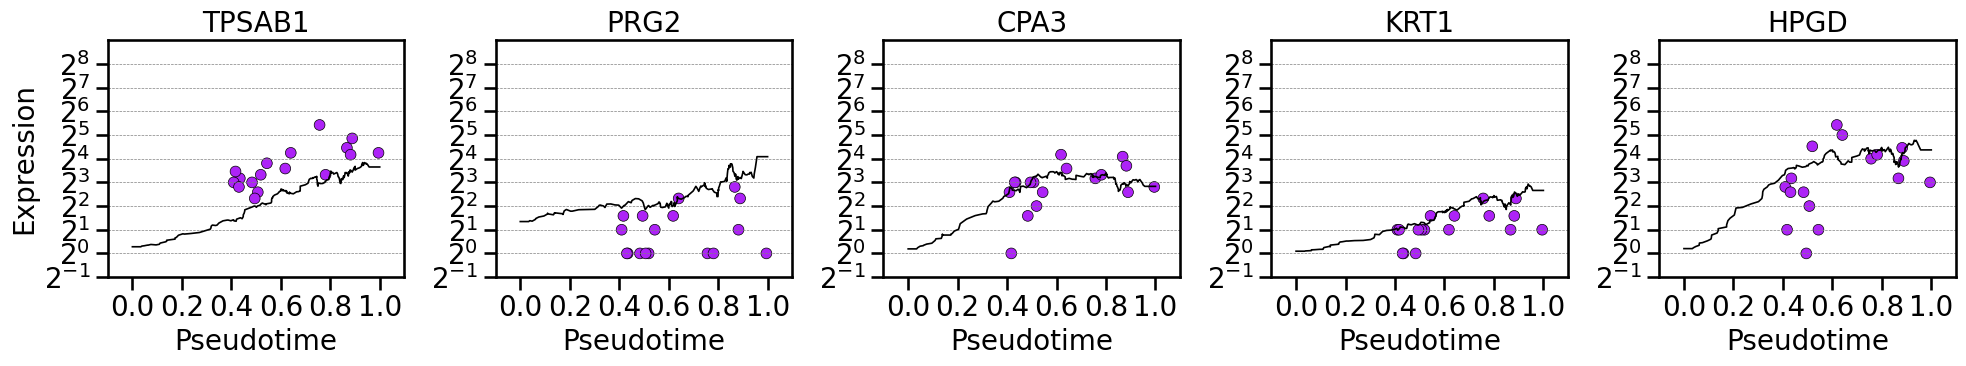

E19_II_5


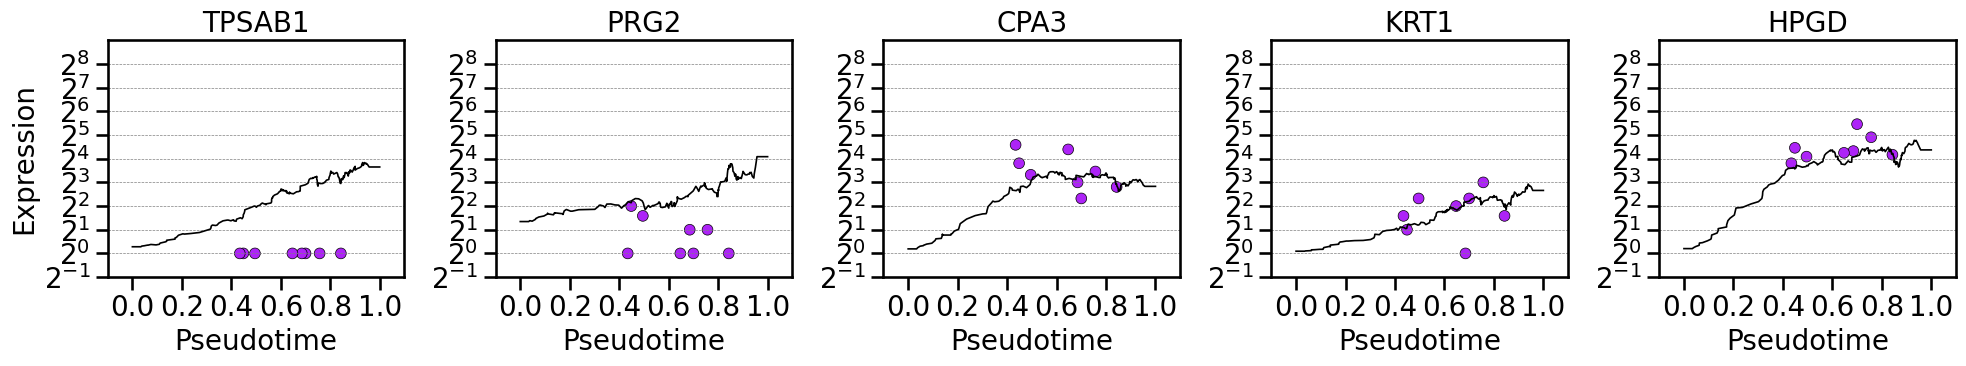

set unnamed.layers[downsampled]: csr_matrix 3252 X 36497 float32s (3867507 > 0, 3.259%)
set unnamed.uns[downsample_samples]: 2048


Downsampling to 2048 UMIs
Cutting downsampled cells, going to remove 732 cells (22.51%)
B9_III_6


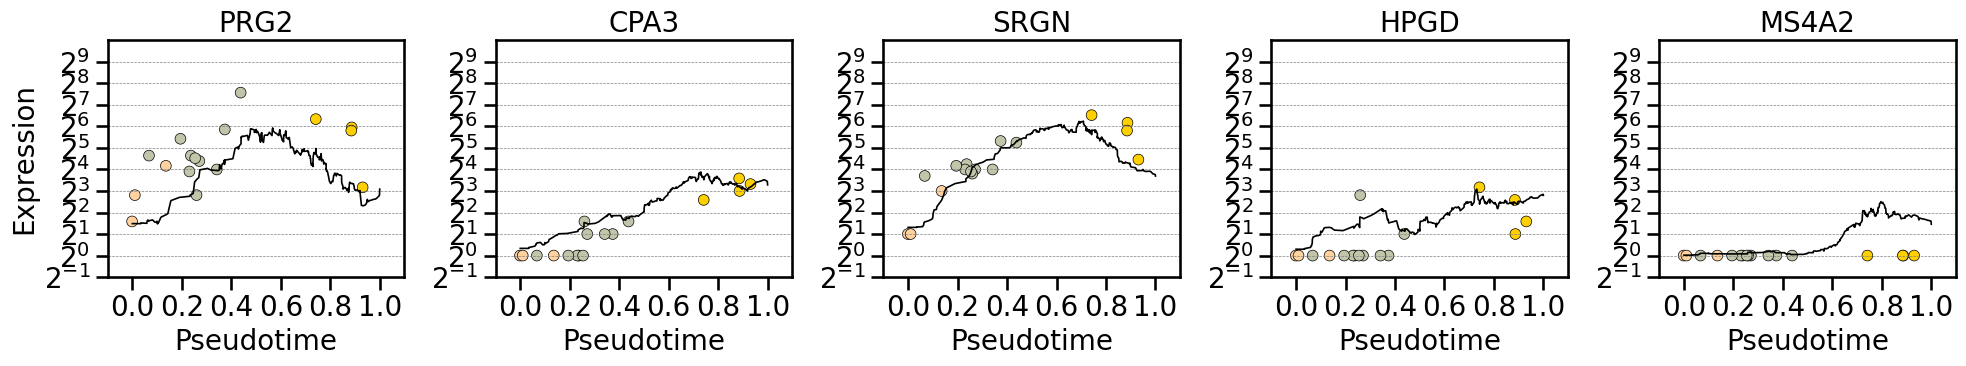

D16_II_5


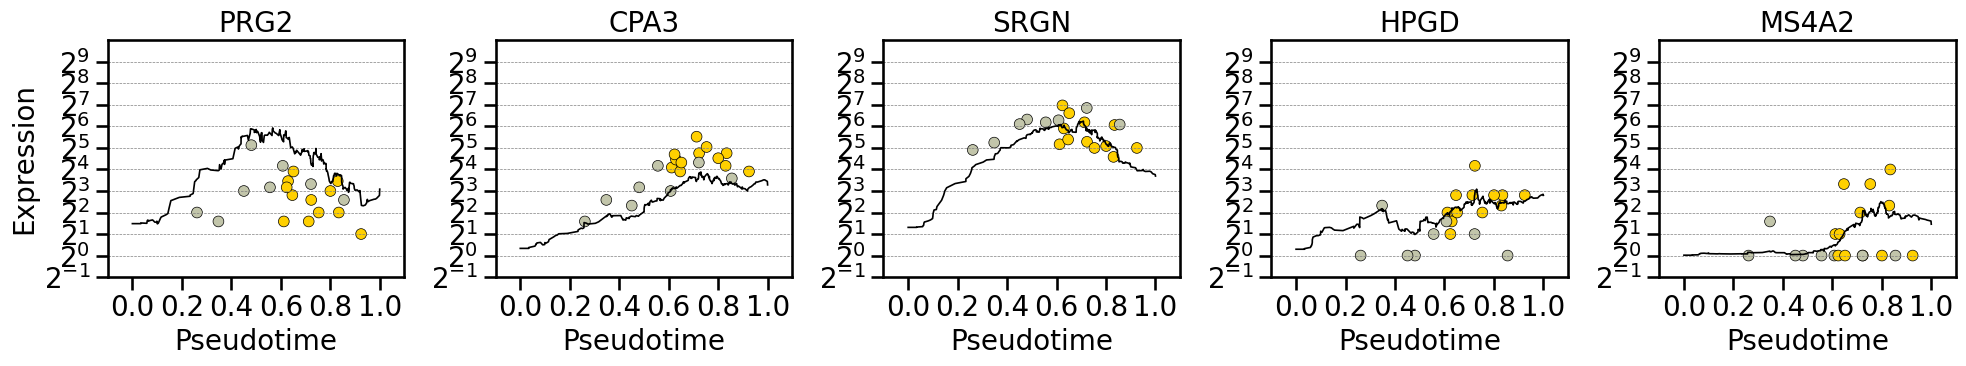

Downsampling to 2048 UMIs


set unnamed.layers[downsampled]: csr_matrix 21651 X 36497 float32s (24030333 > 0, 3.041%)
set unnamed.uns[downsample_samples]: 2048


Cutting downsampled cells, going to remove 1396 cells (6.45%)
4JA6S3RQDTU3NOVPJ4Z44GHPL_I_1


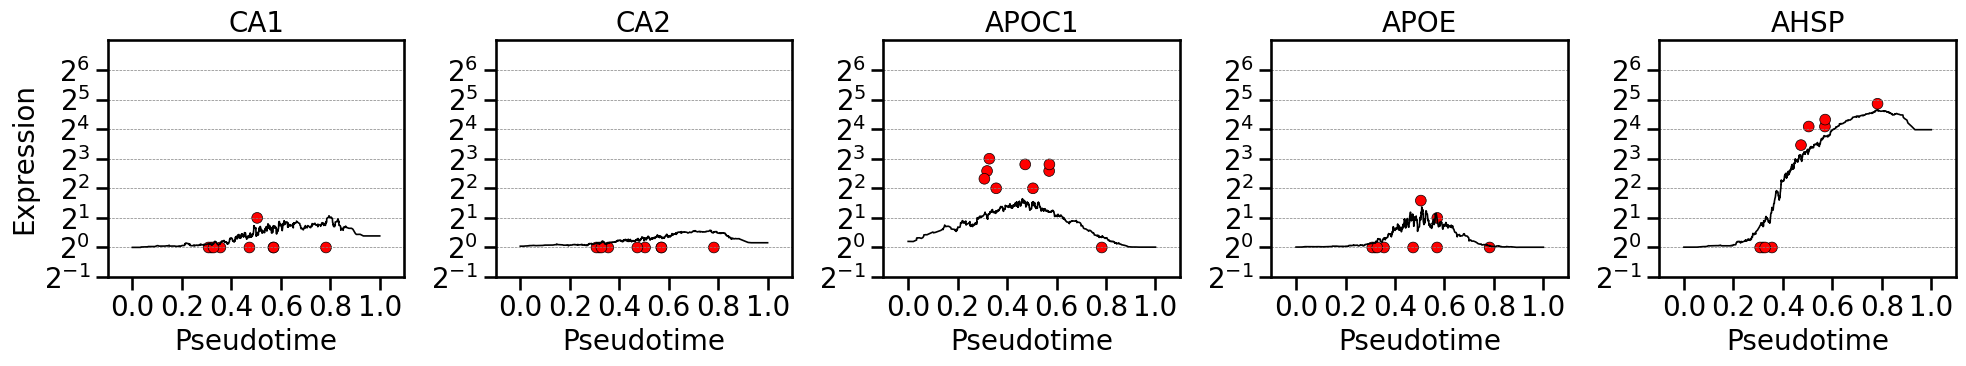

1I0LMJ3K0YLOG8O46XK3ZX64W_I_1


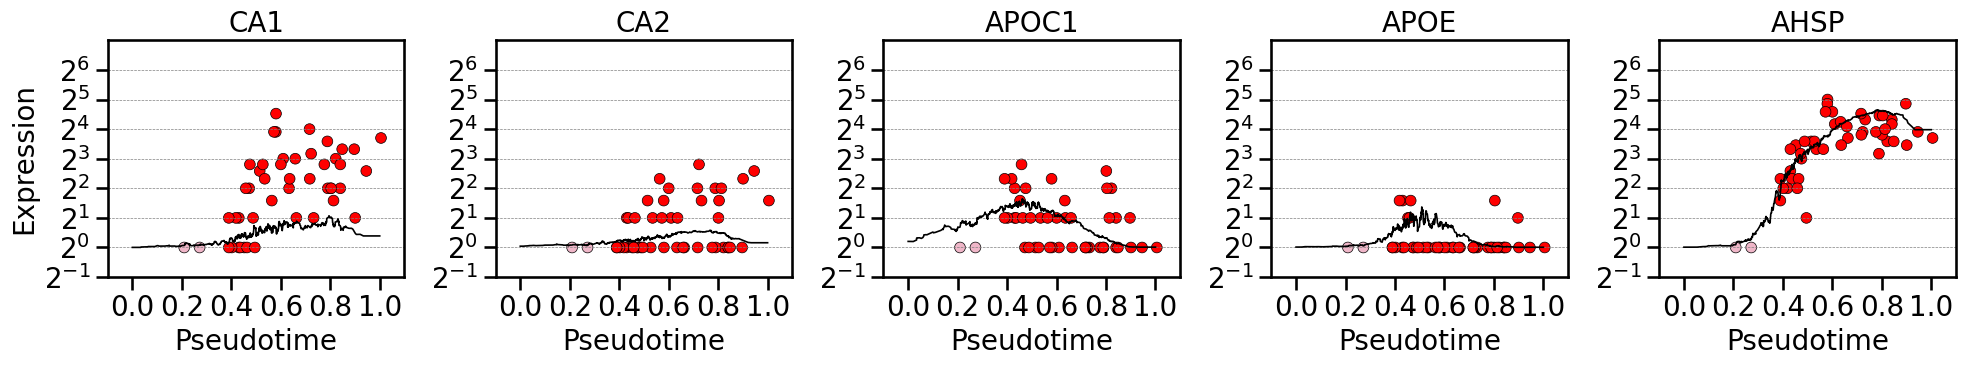

set unnamed.layers[downsampled]: csr_matrix 3911 X 36497 float32s (4663813 > 0, 3.267%)
set unnamed.uns[downsample_samples]: 2048


Downsampling to 2048 UMIs
Cutting downsampled cells, going to remove 810 cells (20.71%)
N12_1_III_7


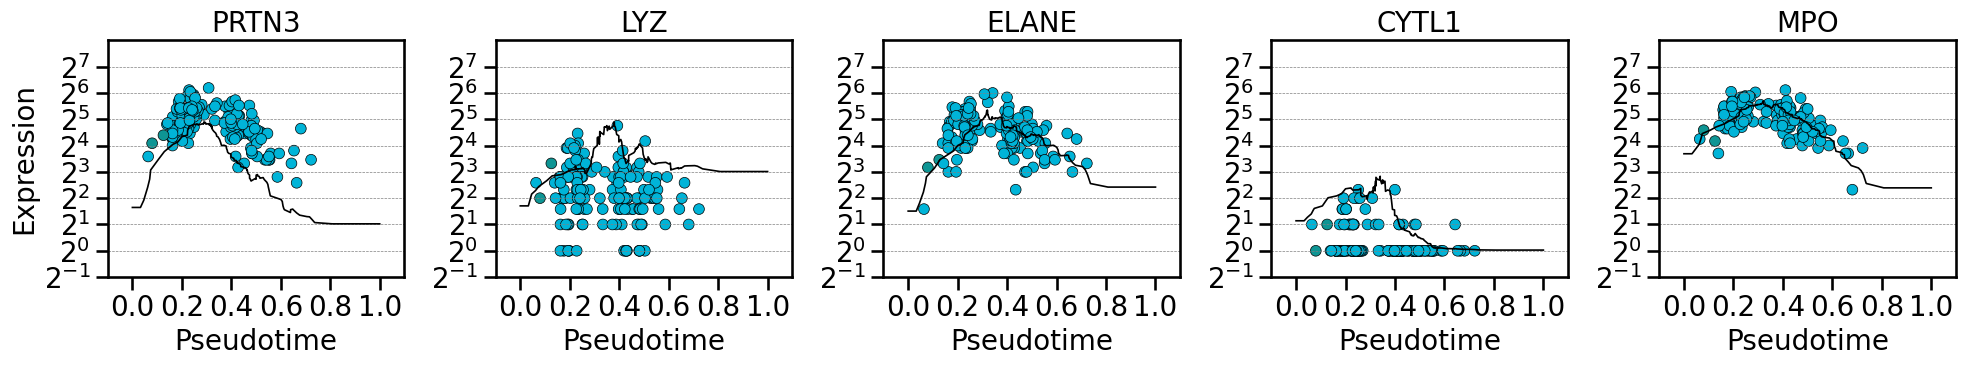

In [58]:
for trajectory in clones_to_show_dict:
    pseudotime_columns = "%s_pseudotime" %trajectory
    info = trajectory_information_dict[trajectory]
    all_wilcoxon_results_df = info["all_wilcoxon_results_df"]

    observed_cells_addata, traj_cells_ad = get_observed_cells_ad(full_cells_ad, trajectory, 8, cell_target_umis = cell_target_umis) 
    observed_cells_df = mc.ut.get_vo_frame(observed_cells_addata, "downsampled")
    trajectory_metacell_umis_df_sampled, trajectory_metacells_ad = get_trajectory_metacells(metacells_ad, metacell_umis_df_sampled, trajectory)

    trajectory_metacells_pseudotime = metacells_ad[trajectory_metacell_umis_df_sampled.index].obs[pseudotime_columns].sort_values()
    trajectory_metacells_pseudotime_smoothed = utils.perform_2d_sliding_window_smoothing(1+ trajectory_metacell_umis_df_sampled.loc[trajectory_metacells_pseudotime.index], sliding_window_size=sliding_window_size)

    clone_ids = clones_to_show_dict[trajectory][0]
    sign_gene = clones_to_show_dict[trajectory][1]
    genes_to_plot = clones_to_show_dict[trajectory][2]
    
    
    max_y_limt = int(np.ceil(np.log2(observed_cells_df[genes_to_plot].max().max())) + 1)

    for clone_id in clone_ids:
        clone_cells = observed_cells_addata.obs_names[observed_cells_addata.obs.clone_exp_id == clone_id]
        observed_semi_df = observed_cells_df.loc[clone_cells,genes_to_plot]
        observed_semi_pseudotime = observed_cells_addata.obs.loc[clone_cells, pseudotime_columns]
        cells_type = observed_cells_addata[observed_cells_addata.obs.clone_exp_id == clone_id].obs.top_level_cell_type
        trajectory_metacells_pseudotime_smoothed_genes = trajectory_metacells_pseudotime_smoothed[genes_to_plot]
        print(clone_id)
        plot_clones_expression(clone_id, genes_to_plot, observed_semi_df, observed_semi_pseudotime, trajectory_metacells_pseudotime, trajectory_metacells_pseudotime_smoothed_genes, "./output", cells_type, ylim_max=max_y_limt,col_width=4,file_prefix="4B_genes", fontsize=20)

In [ ]:
all_clones_list = CloneObject.convert_full_anndata_to_clones_objects(cells_with_clones[cells_with_clones.obs.clone_exp_id.isin(clones_to_show)], ordered_cell_types = [i for i in cell_type_colors.keys() if i not in ["doublets"]])
for clone_sample in all_clones_list:
    print(clone_sample.clone_exp_id)
    clone_sample.make_trajectory_graph(cell_type_colors, min_node_size = 0.1, max_edge_penwidth=10, add_first_day=True,
                                    fig_size=(8,8), nodesep="0.05", ranksep=str(1 / len(clone_sample.sample_day_as_int)),
                                    output_folder="./output", output_file="4B_clones_schematic_%s" %clone_sample.clone_exp_id)

clone_sample.make_node_size_legend(min_node_size=0.1, output_folder="./output", output_file="4B_clones_schematic_legend")

100%|██████████| 7/7 [00:00<00:00, 93.30it/s]


N12_1_III_7
1I0LMJ3K0YLOG8O46XK3ZX64W_I_1
B9_III_6
D16_II_5


C10_2_III_7
4JA6S3RQDTU3NOVPJ4Z44GHPL_I_1
E19_II_5


## Figure 4SC

In [ ]:
metacells_lgc = utils.get_lgc(metacells_ad)

trajectory_lgc_mean_l = []
trajectory_lgc_gap_l = []
for trajectory in constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT:
    trajectory_lgc = metacells_lgc.loc[metacells_ad.obs_names[metacells_ad.obs.type.isin(constants.TRAJECTORIES_TO_TOP_LEVEL_CELL_TYPE_DICT[trajectory])]]
    trajectory_lgc_mean = trajectory_lgc.mean(axis=0)
    trajectory_lgc_gap = trajectory_lgc.max(axis=0) - trajectory_lgc.min(axis=0)
    
    trajectory_genes = final_df_full[final_df_full.trajectory == trajectory].set_index("gene")
    
    mean_df = pd.DataFrame(trajectory_lgc_mean, columns=["expression"])
    mean_df["trajectory"] = trajectory
    
    gap_df = pd.DataFrame(trajectory_lgc_gap, columns=["expression"])
    gap_df["trajectory"] = trajectory
    
    shared_genes = trajectory_genes.index.intersection(mean_df.index)
    mean_df = mean_df.loc[shared_genes]
    gap_df = gap_df.loc[shared_genes]
    trajectory_genes = trajectory_genes.loc[shared_genes]
    
    number_of_clones_per_genes = trajectory_genes.loc[shared_genes].index.value_counts()
    mean_df["#clones"] = number_of_clones_per_genes
    gap_df["#clones"] = number_of_clones_per_genes
    
    
    trajectory_lgc_mean_l.append(mean_df)
    trajectory_lgc_gap_l.append(gap_df)
    
trajectory_lgc_mean = pd.concat(trajectory_lgc_mean_l)
trajectory_lgc_gap = pd.concat(trajectory_lgc_gap_l)

In [ ]:
def rna_fraction_formatter(v, pos):
    if not float(v).is_integer():
        return ""
    return rf"$2^{{{int(v)}}}$"

/tmp/ipykernel_2112079/2065688085.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


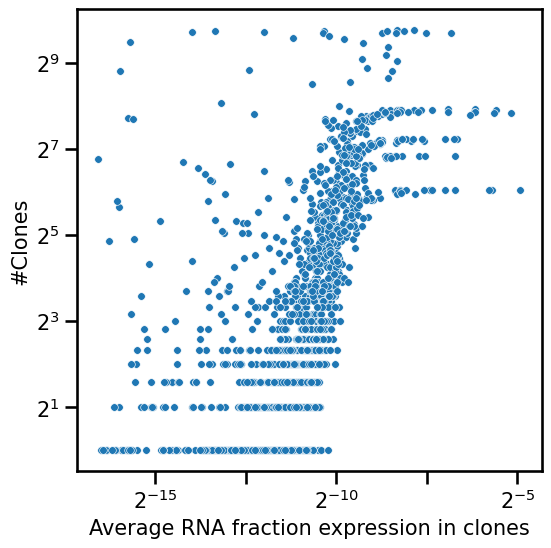

In [ ]:
plt.figure(figsize=(6,6))
s = sb.scatterplot(data=trajectory_lgc_mean, x="expression", y="#clones", s=30)
plt.legend().remove()
plt.yscale("log", base=2)
plt.yscale("log", base=2)
plt.ylabel("#Clones", fontsize=15)
plt.xlabel("Average RNA fraction expression in clones", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
s.xaxis.set_major_formatter(mticker.FuncFormatter(rna_fraction_formatter))
plt.savefig("./output/S4B_mean_expression_vs_clones.pdf", dpi=600, bbox_inches='tight')
plt.show()

## Hemoglobin beta locus (4SA-B)

In [ ]:
sliding_window_size = 5
min_clone_size = 8

In [ ]:
trajectory = "Ery"
pseudotime_columns = "%s_pseudotime" %trajectory
info = trajectory_information_dict[trajectory]
all_wilcoxon_results_df = info["all_wilcoxon_results_df"]

clones_genes_with_significant_tuples = info["clones_genes_with_significant_tuples"]
clones_obs_umis_df_stacked_nonzero_with_epsilon = info["clones_obs_umis_df_stacked_nonzero_with_epsilon"]
clones_exp_umis_df_stacked_nonzero_with_epsilon = info["clones_exp_umis_df_stacked_nonzero_with_epsilon"]
clones_exp_umis_df_stacked_nonzero_logfold = np.log2(clones_obs_umis_df_stacked_nonzero_with_epsilon / clones_exp_umis_df_stacked_nonzero_with_epsilon)

hbg_results = all_wilcoxon_results_df[all_wilcoxon_results_df.gene.isin(["HBG1", "HBG2"])]

hbg_valid_clones = hbg_results[hbg_results.valid_gene].clone.unique()
hbg_valid_clone_high = hbg_results[(hbg_results.valid_gene) & (hbg_results.direction_sum > 0)].clone.unique()
hbg_valid_clone_low = hbg_results[(hbg_results.valid_gene) & (hbg_results.direction_sum < 0)].clone.unique()
hbg_no_valid_clones = pd.Index(set(hbg_results.clone.unique()) - set(hbg_valid_clones))

In [ ]:
hbb_logfold = clones_exp_umis_df_stacked_nonzero_logfold[clones_exp_umis_df_stacked_nonzero_logfold.index.get_level_values(1) == "HBB"]
hbb_logfold_in_high_hbg = hbb_logfold[hbb_logfold.index.get_level_values(0).isin(hbg_valid_clone_high)]
hbb_logfold_in_low_hbg = hbb_logfold[hbb_logfold.index.get_level_values(0).isin(hbg_valid_clone_low)]
hbb_logfold_in_no_valid_clones = hbb_logfold[hbb_logfold.index.get_level_values(0).isin(hbg_no_valid_clones)]

hbd_logfold = clones_exp_umis_df_stacked_nonzero_logfold[clones_exp_umis_df_stacked_nonzero_logfold.index.get_level_values(1) == "HBD"]
hbd_logfold_in_high_hbg = hbd_logfold[hbd_logfold.index.get_level_values(0).isin(hbg_valid_clone_high)]
hbd_logfold_in_low_hbg = hbd_logfold[hbd_logfold.index.get_level_values(0).isin(hbg_valid_clone_low)]
hbd_logfold_in_no_valid_clones = hbd_logfold[hbd_logfold.index.get_level_values(0).isin(hbg_no_valid_clones)]

In [ ]:
def pairwise_ks_with_mc(data_dict, method_fdr='fdr_bh'):
    rows = []
    for a, b in combinations(data_dict.keys(), 2):
        x, y = np.asarray(data_dict[a]), np.asarray(data_dict[b])
        stat, p = ks_2samp(x, y, alternative='two-sided', mode='auto')
        rows.append({"group1": a, "group2": b, "KS_stat": stat, "p_raw": p})
    df = pd.DataFrame(rows)
    
    # multiple corrections using statsmodels
    pvals = df["p_raw"].values
    _, p_bonf, _, _ = multipletests(pvals, method='bonferroni')
    _, p_fdr, _, _ = multipletests(pvals, method=method_fdr)
    
    df["p_bonf"] = p_bonf
    df["p_fdr_bh"] = p_fdr
    return df.sort_values("p_raw").reset_index(drop=True)

# example usage
hbb_results = pairwise_ks_with_mc({
    "high_hbg": hbb_logfold_in_high_hbg,
    "low_hbg": hbb_logfold_in_low_hbg,
    "no_valid_clones": hbb_logfold_in_no_valid_clones
})


hbd_results = pairwise_ks_with_mc({
    "high_hbg": hbd_logfold_in_high_hbg,
    "low_hbg": hbd_logfold_in_low_hbg,
    "no_valid_clones": hbd_logfold_in_no_valid_clones
})

print(hbb_results)
print(hbd_results)

     group1           group2   KS_stat         p_raw        p_bonf  \
0  high_hbg          low_hbg  0.938053  3.247539e-40  9.742618e-40   
1   low_hbg  no_valid_clones  0.457608  7.940351e-38  2.382105e-37   
2  high_hbg  no_valid_clones  0.672215  1.575339e-17  4.726018e-17   

       p_fdr_bh  
0  9.742618e-40  
1  1.191053e-37  
2  1.575339e-17  
     group1           group2   KS_stat         p_raw        p_bonf  \
0  high_hbg          low_hbg  0.757059  3.390390e-22  1.017117e-21   
1  high_hbg  no_valid_clones  0.643160  6.529898e-16  1.958969e-15   
2   low_hbg  no_valid_clones  0.154917  1.314360e-04  3.943079e-04   

       p_fdr_bh  
0  1.017117e-21  
1  9.794847e-16  
2  1.314360e-04  


In [ ]:
def pairwise_ks_with_mc(data_dict, method_fdr='fdr_bh'):
    rows = []
    for a, b in combinations(data_dict.keys(), 2):
        x, y = np.asarray(data_dict[a]), np.asarray(data_dict[b])
        stat, p = ks_2samp(x, y, alternative='two-sided', mode='auto')
        rows.append({"group1": a, "group2": b, "KS_stat": stat, "p_raw": p})
    df = pd.DataFrame(rows)
    
    # multiple corrections using statsmodels
    pvals = df["p_raw"].values
    _, p_bonf, _, _ = multipletests(pvals, method='bonferroni')
    _, p_fdr, _, _ = multipletests(pvals, method=method_fdr)
    
    df["p_bonf"] = p_bonf
    df["p_fdr_bh"] = p_fdr
    return df.sort_values("p_raw").reset_index(drop=True)

# example usage
hbb_results = pairwise_ks_with_mc({
    "high_hbg": hbb_logfold_in_high_hbg,
    "low_hbg": hbb_logfold_in_low_hbg,
    "no_valid_clones": hbb_logfold_in_no_valid_clones
})


hbd_results = pairwise_ks_with_mc({
    "high_hbg": hbd_logfold_in_high_hbg,
    "low_hbg": hbd_logfold_in_low_hbg,
    "no_valid_clones": hbd_logfold_in_no_valid_clones
})

print(hbb_results)
print(hbd_results)

     group1           group2   KS_stat         p_raw        p_bonf  \
0  high_hbg          low_hbg  0.938053  3.247539e-40  9.742618e-40   
1   low_hbg  no_valid_clones  0.457608  7.940351e-38  2.382105e-37   
2  high_hbg  no_valid_clones  0.672215  1.575339e-17  4.726018e-17   

       p_fdr_bh  
0  9.742618e-40  
1  1.191053e-37  
2  1.575339e-17  
     group1           group2   KS_stat         p_raw        p_bonf  \
0  high_hbg          low_hbg  0.757059  3.390390e-22  1.017117e-21   
1  high_hbg  no_valid_clones  0.643160  6.529898e-16  1.958969e-15   
2   low_hbg  no_valid_clones  0.154917  1.314360e-04  3.943079e-04   

       p_fdr_bh  
0  1.017117e-21  
1  9.794847e-16  
2  1.314360e-04  


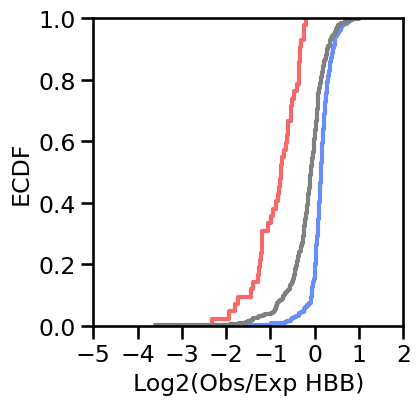

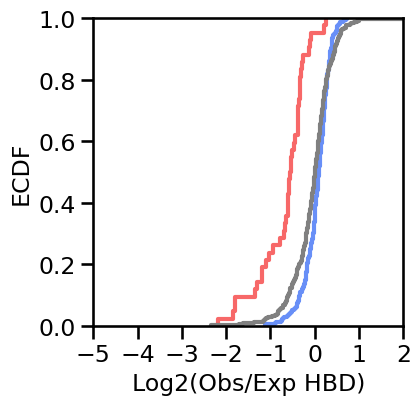

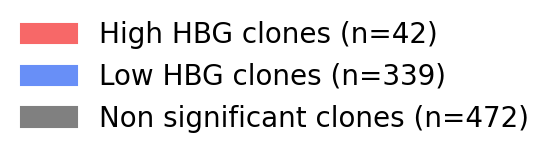

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(4,4))
sb.ecdfplot(hbb_logfold_in_high_hbg.values, color="#F76868", linewidth=3)
sb.ecdfplot(hbb_logfold_in_low_hbg.values, color="#688FF7", linewidth=3)
sb.ecdfplot(hbb_logfold_in_no_valid_clones.values, color="gray", linewidth=3)
plt.xlabel("Log2(Obs/Exp HBB)", fontsize=17)
plt.ylabel("ECDF", fontsize=17)
plt.xlim(-5,2)
plt.yticks(np.arange(0,1.1,0.2), fontsize=17)
plt.xticks(np.arange(-5,3,1), fontsize=17)
plt.savefig("./output/4SA_HBB_ECDF.pdf", dpi=600, bbox_inches='tight')
plt.show()


plt.figure(figsize=(4,4))
sb.ecdfplot(hbd_logfold_in_high_hbg.values, color="#F76868", linewidth=3)
sb.ecdfplot(hbd_logfold_in_low_hbg.values, color="#688FF7", linewidth=3)
sb.ecdfplot(hbd_logfold_in_no_valid_clones.values, color="gray", linewidth=3)
plt.xlabel("Log2(Obs/Exp HBD)", fontsize=17)
plt.ylabel("ECDF", fontsize=17)
plt.xlim(-5,2)
plt.yticks(np.arange(0,1.1,0.2), fontsize=17)
plt.xticks(np.arange(-5,3,1), fontsize=17)
plt.savefig("./output/4SA_HBD_ECDF.pdf", dpi=600, bbox_inches='tight')
plt.show()  


utils.plot_generic_dict_of_colors({
    "High HBG clones (n=%d)" % len(hbg_valid_clone_high):"#F76868",
    "Low HBG clones (n=%d)" % len(hbg_valid_clone_low):"#688FF7",
    "Non significant clones (n=%d)" % len(hbg_no_valid_clones):"gray",
}, output_path="./output/4SA_HBG_legend.pdf")

In [ ]:
all_wilcoxon_results_df[(all_wilcoxon_results_df.clone == "O4_I_3") & (all_wilcoxon_results_df.gene.isin(["HBB","HBD","HBG1", "HBG2"]))]

,clone,gene,obs_minus_exp_sum,chisq_stat,chisq_pval,wilcoxon_pval,frac_pos,frac_neg,frac_eq,direction_majority,direction_sum,chisq_pval_adj,significant,direction_agreement,valid_gene,trajectory
48065,O4_I_3,HBB,-1119.0,463.591633,7.948707e-103,0.000976,0.217391,0.782609,0.000000,-1,-1.0,2.405735e-100,True,True,True,Ery
48066,O4_I_3,HBD,-91.0,38.696262,4.951565e-10,0.006692,0.217391,0.695652,0.086957,0,-1.0,2.077060e-08,True,False,False,Ery
48067,O4_I_3,HBG1,647.0,1224.002924,3.705415e-268,0.000043,0.913043,0.043478,0.043478,1,1.0,2.630741e-265,True,True,True,Ery
48068,O4_I_3,HBG2,548.0,690.354023,3.743742e-152,0.001075,0.782609,0.173913,0.043478,1,1.0,1.682845e-149,True,True,True,Ery


Downsampling to 2048 UMIs


set unnamed.layers[downsampled]: csr_matrix 21651 X 36497 float32s (24030333 > 0, 3.041%)
set unnamed.uns[downsample_samples]: 2048


Cutting downsampled cells, going to remove 1396 cells (6.45%)
O4_I_3


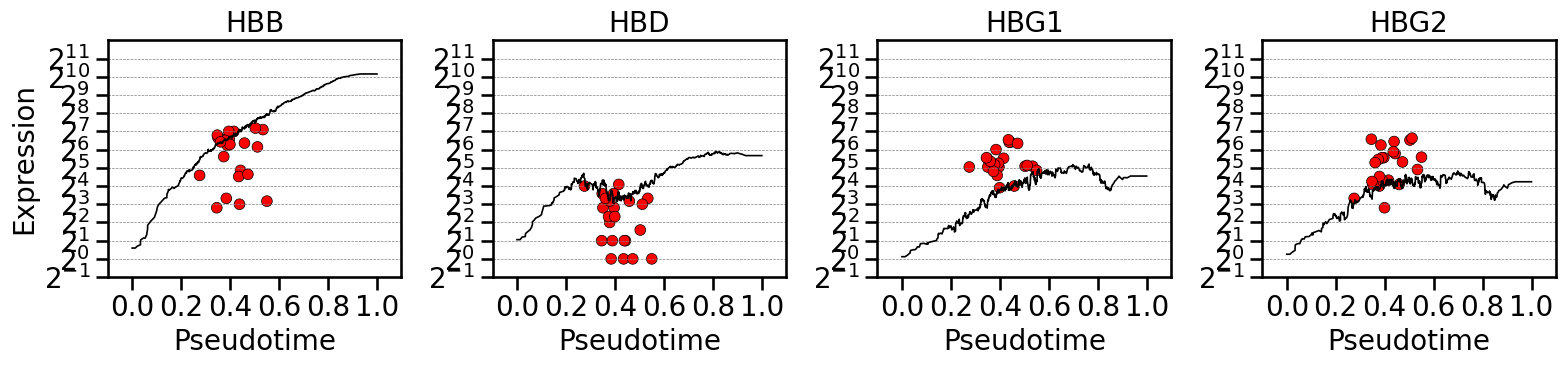

O9_I_7


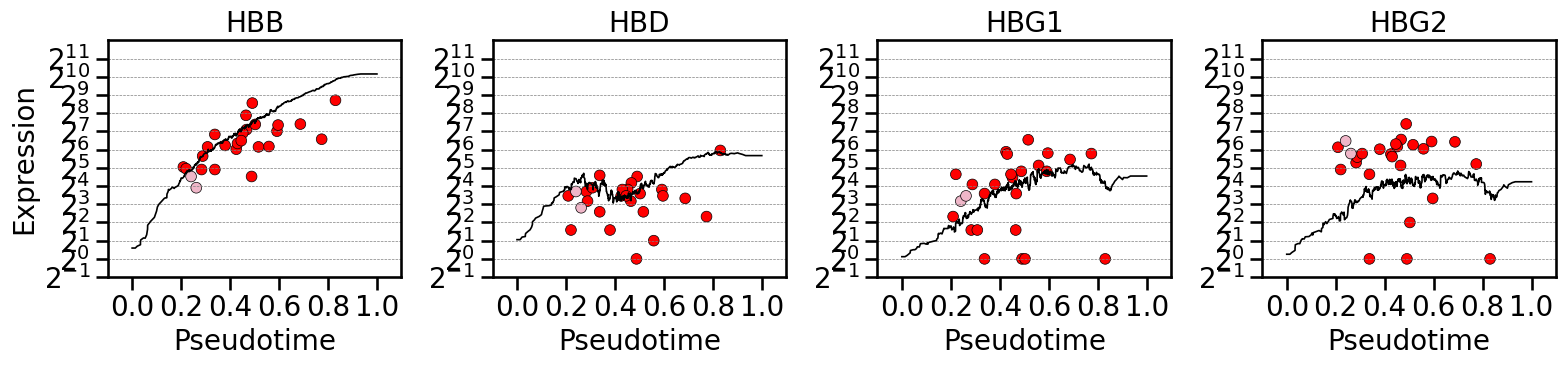

In [ ]:
sliding_window_size = 5

clones_to_show = []
clones_to_show_dict = {
    "Ery":(['O4_I_3', 'O9_I_7'], "HBG1", ["HBB","HBD","HBG1","HBG2"]),
}


for trajectory in clones_to_show_dict:
    pseudotime_columns = "%s_pseudotime" %trajectory
    info = trajectory_information_dict[trajectory]
    all_wilcoxon_results_df = info["all_wilcoxon_results_df"]

    observed_cells_addata, traj_cells_ad = get_observed_cells_ad(full_cells_ad, trajectory, 8, cell_target_umis = cell_target_umis) 
    observed_cells_df = mc.ut.get_vo_frame(observed_cells_addata, "downsampled")
    trajectory_metacell_umis_df_sampled, trajectory_metacells_ad = get_trajectory_metacells(metacells_ad, metacell_umis_df_sampled, trajectory)

    trajectory_metacells_pseudotime = metacells_ad[trajectory_metacell_umis_df_sampled.index].obs[pseudotime_columns].sort_values()
    trajectory_metacells_pseudotime_smoothed = utils.perform_2d_sliding_window_smoothing(1+ trajectory_metacell_umis_df_sampled.loc[trajectory_metacells_pseudotime.index], sliding_window_size=sliding_window_size)

    clone_ids = clones_to_show_dict[trajectory][0]
    sign_gene = clones_to_show_dict[trajectory][1]
    genes_to_plot = clones_to_show_dict[trajectory][2]
	
    max_y_limt = int(np.ceil(np.log2(observed_cells_df[genes_to_plot].max().max())) + 1)

    for clone_id in clone_ids:
        clone_cells = observed_cells_addata.obs_names[observed_cells_addata.obs.clone_exp_id == clone_id]
        observed_semi_df = observed_cells_df.loc[clone_cells,genes_to_plot]
        observed_semi_pseudotime = observed_cells_addata.obs.loc[clone_cells, pseudotime_columns]
        cells_type = observed_cells_addata[observed_cells_addata.obs.clone_exp_id == clone_id].obs.top_level_cell_type
        trajectory_metacells_pseudotime_smoothed_genes = trajectory_metacells_pseudotime_smoothed[genes_to_plot]
        print(clone_id)
        plot_clones_expression(clone_id, genes_to_plot, observed_semi_df, observed_semi_pseudotime, trajectory_metacells_pseudotime, trajectory_metacells_pseudotime_smoothed_genes, "./output", cells_type, ylim_max=max_y_limt,col_width=4,file_prefix="4SA_genes", fontsize=20)

## 4SD

In [ ]:
all_wilcoxon_results_df = pd.concat(all_wilcoxon_results_df_list)
clones_avg_logfold_genes = pd.concat(clones_avg_logfold_genes_list)
sign_clones_logfold = pd.concat(sign_clones_logfold_list)
final_df_full = pd.concat(final_df_full_list)

clones_avg_logfold_genes.gene = pd.Categorical(clones_avg_logfold_genes.gene, categories=sign_clones_logfold.gene.value_counts().index, ordered=True)
sign_clones_logfold.gene = pd.Categorical(sign_clones_logfold.gene, categories=sign_clones_logfold.gene.value_counts().index, ordered=True)

valid_genes_list = all_wilcoxon_results_df[all_wilcoxon_results_df.valid_gene]
all_wilcoxon_results_df = all_wilcoxon_results_df[all_wilcoxon_results_df.valid_gene]
all_wilcoxon_results_df = all_wilcoxon_results_df[~all_wilcoxon_results_df.gene.isin(lateral_genes)]
all_wilcoxon_results_df = all_wilcoxon_results_df[all_wilcoxon_results_df.trajectory != "Monocyte"] # too few clones


final_df_full = final_df_full[~final_df_full.gene.isin(lateral_genes)]
final_df_full = final_df_full[final_df_full.trajectory != "Monocyte"] # too few clones

In [ ]:
# appear in the trajectory more then one time 
all_wilcoxon_results_df = all_wilcoxon_results_df[all_wilcoxon_results_df.groupby(["trajectory", "gene"]).gene.transform("size") > 1]


x = 15  # number of top genes to keep

# count how many times each gene appears per trajectory
gene_counts = (
    all_wilcoxon_results_df
    .groupby(['trajectory', 'gene'])
    .size()
    .reset_index(name='count')
)

# get top x genes per trajectory
top_genes = (
    gene_counts
    .sort_values(['trajectory', 'count'], ascending=[True, False])
    .groupby('trajectory', group_keys=False)
    .head(x)
)

df = all_wilcoxon_results_df.merge(
    filtered[['trajectory', 'gene']].drop_duplicates(),
    on=['trajectory', 'gene']
)

majority = (
    df.groupby(['clone', 'gene'])['direction_majority']  
    .mean()
    .reset_index()
)

majority['sign_majority'] = majority['direction_majority'].apply(
    lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
)

In [ ]:
mat = majority.pivot(index='clone', columns='gene', values='sign_majority').fillna(0)

In [ ]:
memory_gene_gene_correlation = pd.DataFrame(
    np.corrcoef(mat.T),
    index=mat.columns,
    columns=mat.columns
)

In [ ]:
memory_gene_gene_correlation = pd.DataFrame(np.corrcoef(mat.T), index=mat.columns, columns=mat.columns)

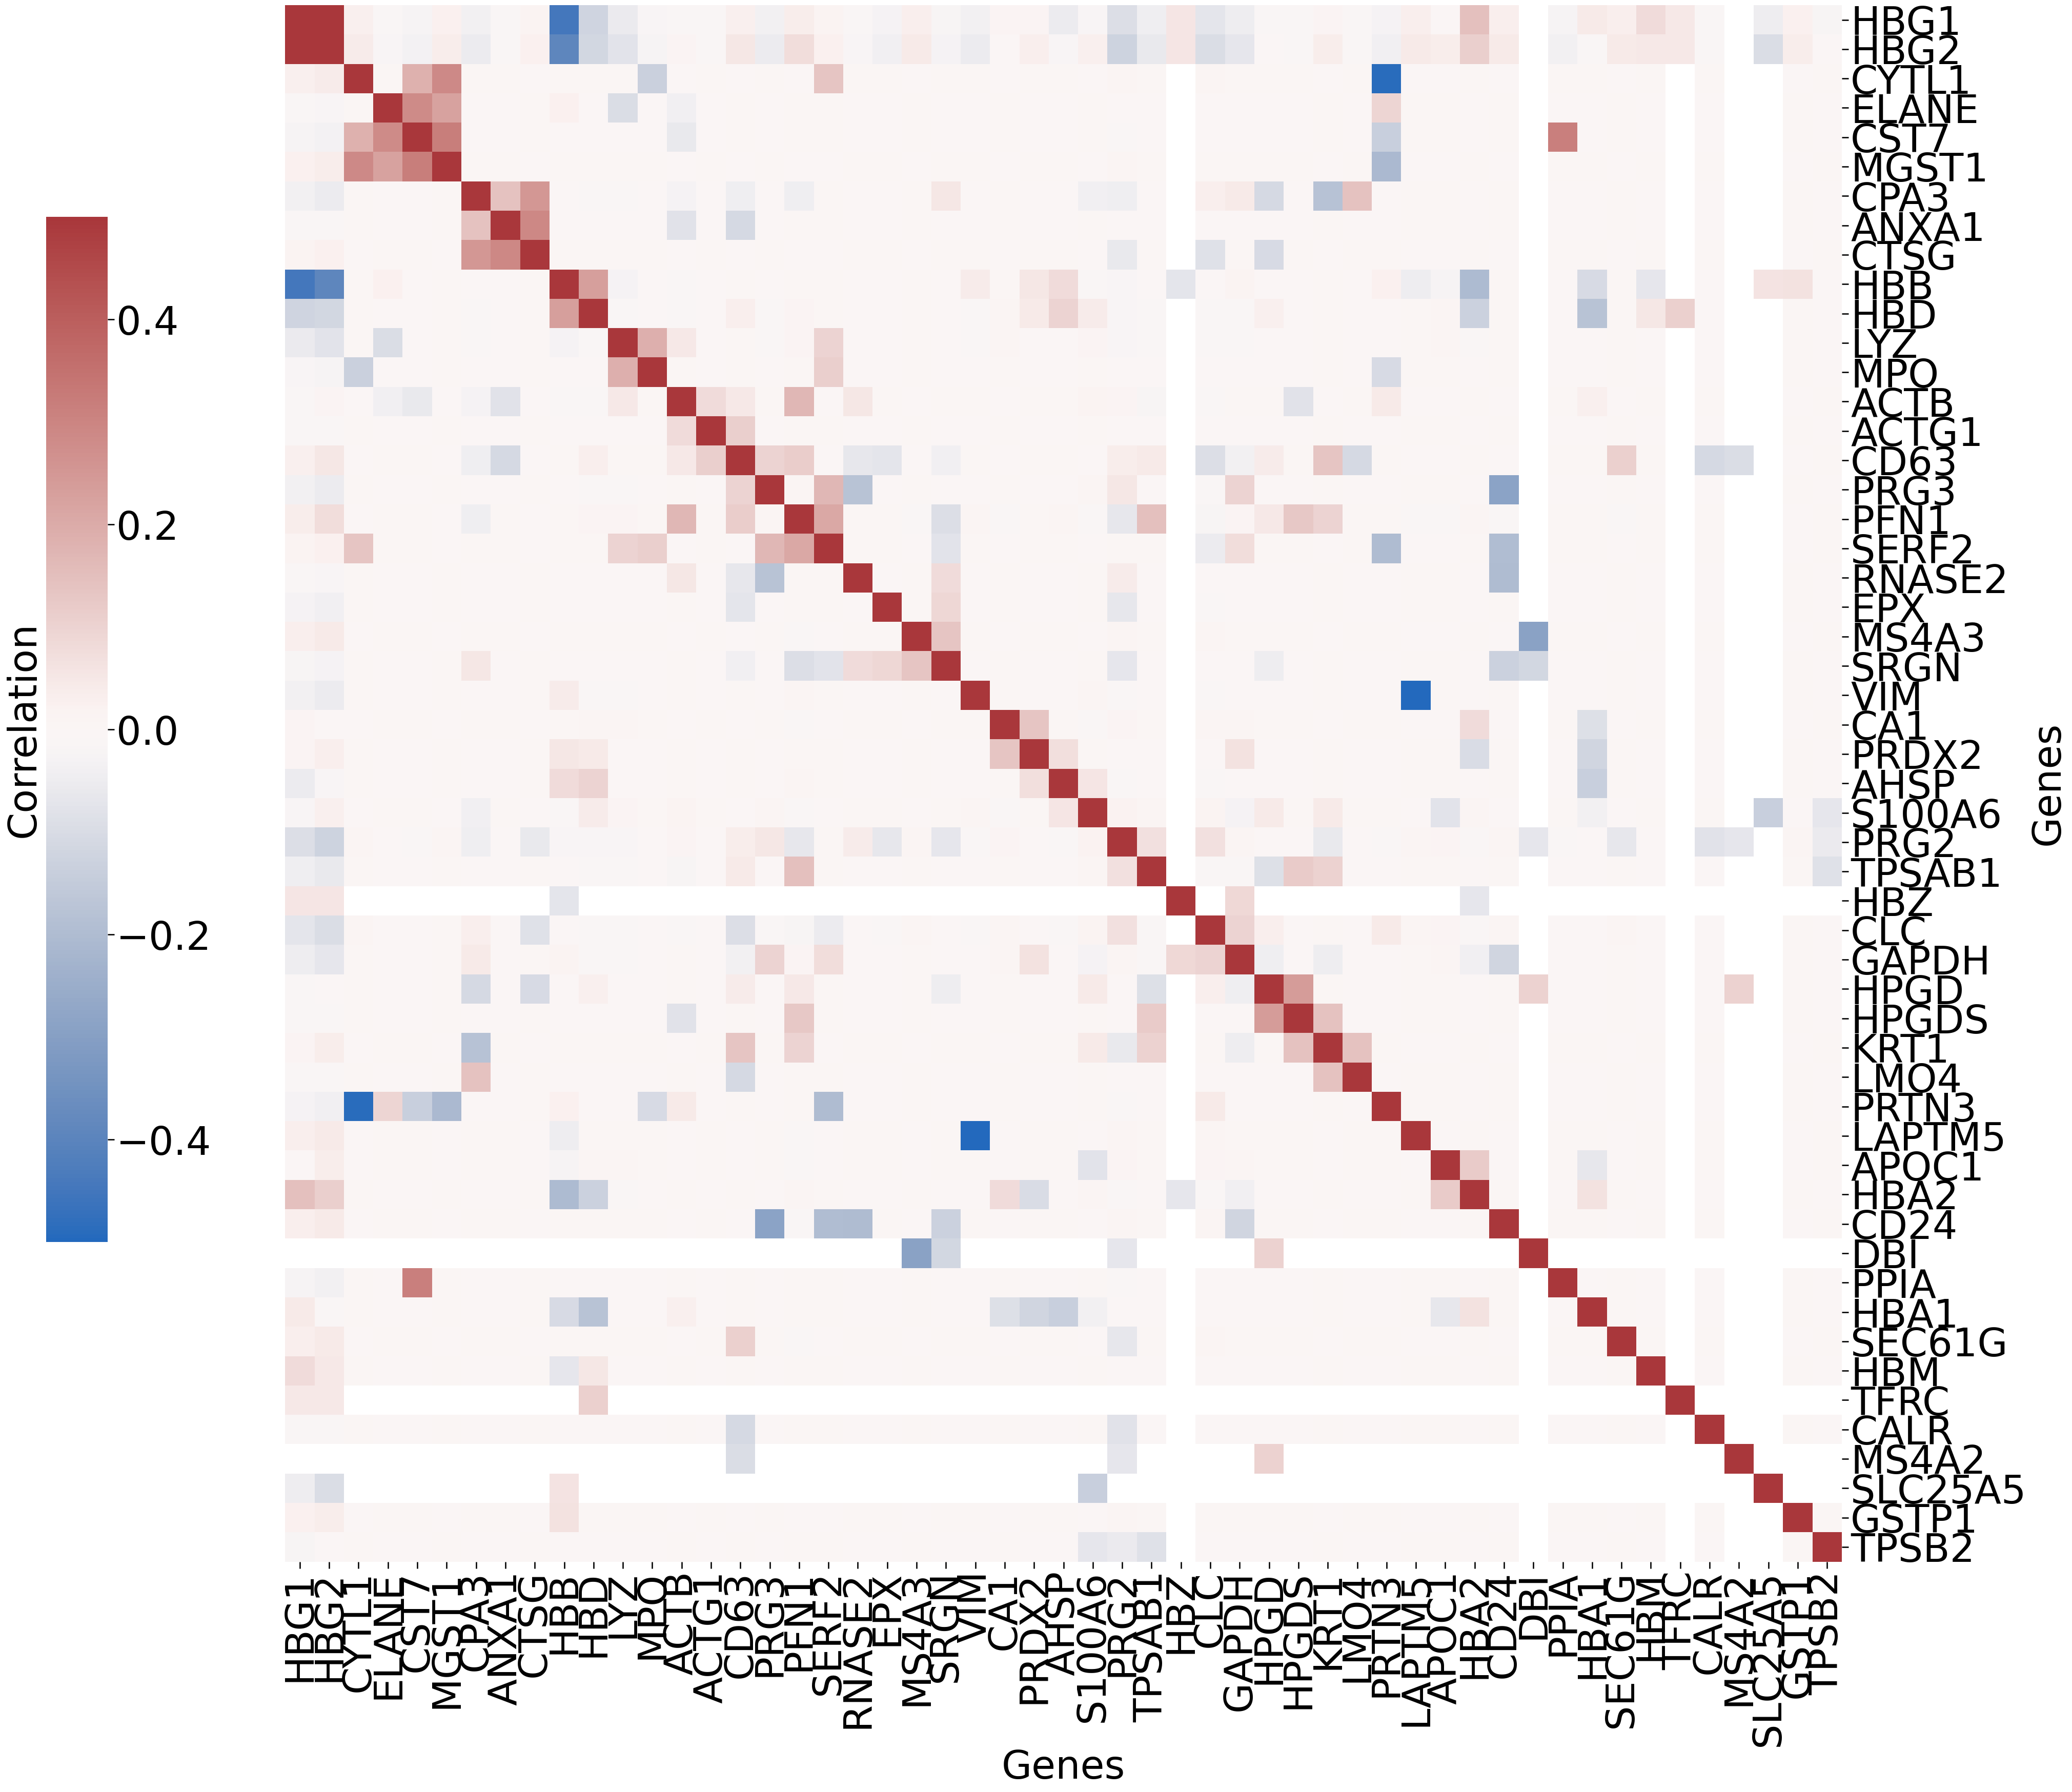

In [ ]:
g = sb.clustermap(memory_gene_gene_correlation, cmap="vlag", vmin=-0.5, vmax=0.5, center=0, 
                  figsize=(40,40), 
                  method="ward", mask=memory_gene_gene_correlation==0,
                  cbar_pos=(0.08, 0.2, 0.03, 0.5))

g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

# Update tick font sizes
for ax in [g.ax_heatmap, g.ax_col_colors, g.ax_row_colors]:
    if ax is not None:
        ax.tick_params(labelsize=55)

# Colorbar ticks
if g.cax is not None:
    g.cax.tick_params(labelsize=55)
    g.cax.set_ylabel("Correlation", fontsize=55)
    g.cax.yaxis.set_label_position("left")

# Axis labels if visible (not xticklabels=False)
g.ax_heatmap.set_xlabel("Genes", fontsize=55)
g.ax_heatmap.set_ylabel("Genes", fontsize=55)
g.savefig("./output/S4D_memory_genes_correlation_clustermap.pdf", dpi=600, bbox_inches='tight')
plt.show()
